# Example-25: Twiss from reconstructed TbT momenta

In [1]:
# Using TbT coordinates, it is possible to compute a subset of normalization matrix elements
# In particular, elemets n11, n33, n13, n14, n31 and n32 can be computed
# Normalization matrix has eight free elements (ten elements in general, but n12 = n34 = 0 by definition)
# Two more elements are required to fully characterize normalization matrix

# In these example all remainint elements are computed from harmonic decomposition of reconstructed momenta
# Expressions for normalizaton matrix elements are the following (can be obtained from amplitudes and phases)

# n21 -> axx/(2*ix).sqrt()*(fxx - fx).cos()
# n22 -> axx/(2*ix).sqrt()*(fxx - fx).sin()
# n23 -> axy/(2*iy).sqrt()*(fxy - fy).cos()
# n24 -> axy/(2*iy).sqrt()*(fxy - fy).sin()
# n41 -> ayx/(2*ix).sqrt()*(fyx - fx).cos()
# n42 -> ayx/(2*ix).sqrt()*(fyx - fx).sin()
# n43 -> ayy/(2*iy).sqrt()*(fyy - fy).cos()
# n44 -> ayy/(2*iy).sqrt()*(fyy - fy).sin()

# Here fx and fy are fxx and fyy computed from coordinates

# Eight elements can be obtained from harmonic analysis of reconstructed momenta
# Together with elements computed from coodrinates, all fourteen normalization elements can be estimated

## Import & definitions

In [2]:
# Import

import sys
sys.path.append('..')

from torch import Tensor
from numpy import ndarray as Array

import numpy
import torch

from harmonica.util import mod

from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

from harmonica.parameterization import twiss_phase_advance
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs
from harmonica.parameterization import invariant
from harmonica.parameterization import parametric_normal
from harmonica.parameterization import id_symplectic

from harmonica.statistics import root_mean_square

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

In [3]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

## Model setup

In [4]:
# Load lodel

model = Model(path='../config/skif.yaml', model='uncoupled', dtype=dtype, device=device)

# Number of monitor and virtual locations
# Calibration errors are added to monitor locations, normal and skew quadrupole errors are added to virtual locations

print(model.monitor_count)
print(model.virtual_count)

224
753


In [5]:
# Set full TbT length (full length is used for frequency estimation)

length:int = 2*2**10

In [6]:
# Set window function (frequency estimation) 

window:Window = Window.from_cosine(length, 2.0, dtype=dtype, device=device)

In [7]:
# Set data containers

tbt_x:Data = Data(model.monitor_count, window)
tbt_y:Data = Data(model.monitor_count, window)

In [8]:
# Set frequency containers

f_x:Frequency = Frequency(tbt_x)
f_y:Frequency = Frequency(tbt_y)

In [9]:
# Set decomposition containers

d_x:Decomposition = Decomposition(tbt_x)
d_y:Decomposition = Decomposition(tbt_y)

In [10]:
# Initialize zero focusing errors for all locations

kn:Tensor = torch.zeros(model.size, dtype=dtype, device=device)
ks:Tensor = torch.zeros(model.size, dtype=dtype, device=device)

In [11]:
# Set weak focusing errors at all virtual locations

kn[model.virtual_index] = 0.5E-3*torch.randn(model.virtual_count, dtype=dtype, device=device)
ks[model.virtual_index] = 0.5E-3*torch.randn(model.virtual_count, dtype=dtype, device=device)

In [12]:
# Compute twiss parametes with quadrupole errors (beam frame twiss parameters)

model.make_error(kn, ks, length=0.0)
model.make_transport(error=True, exact=False)
model.make_twiss()

True

In [13]:
# Compute phase advanced between monitors  (beam frame twiss parameters)

nux, nuy = model.out_tune_fractional
mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(nux, mux)
muy, _ = Decomposition.phase_adjacent(nuy, muy)

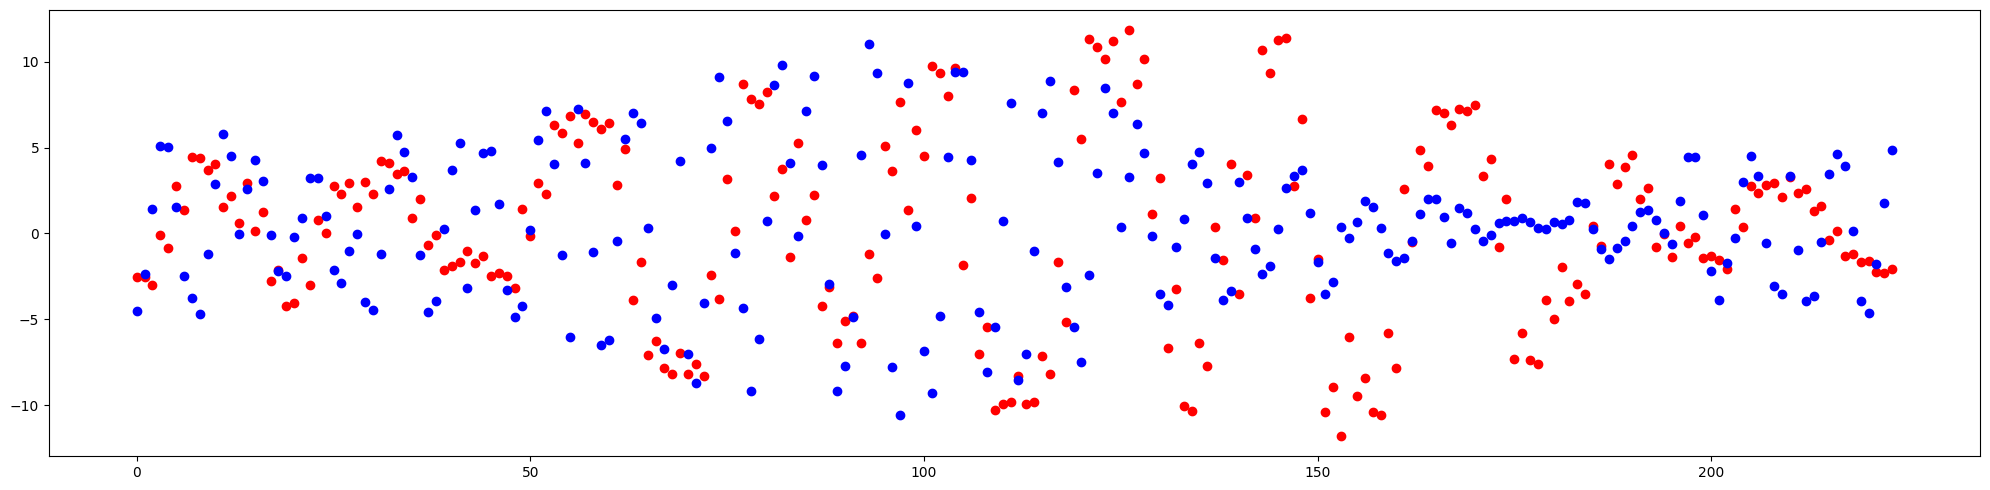

5.41
4.30


In [14]:
# Compare with model

_, bx, _, by = model.out_cs[model.monitor_index].T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*(((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index])).cpu().numpy(), color='red')
plt.scatter(range(model.monitor_count), 100*(((model.by[model.monitor_index] - by)/model.by[model.monitor_index])).cpu().numpy(), color='blue')
plt.tight_layout()
plt.show()

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by)/model.by[model.monitor_index]).item():.2f}')

In [15]:
# Set twiss parameters

normal = model.out_normal[model.monitor_index]

n11 = normal[:, 0, 0]
n12 = normal[:, 0, 1]
n13 = normal[:, 0, 2]
n14 = normal[:, 0, 3]

n21 = normal[:, 1, 0]
n22 = normal[:, 1, 1]
n23 = normal[:, 1, 2]
n24 = normal[:, 1, 3]

n31 = normal[:, 2, 0]
n32 = normal[:, 2, 1]
n33 = normal[:, 2, 2]
n34 = normal[:, 2, 3]

n41 = normal[:, 3, 0]
n42 = normal[:, 3, 1]
n43 = normal[:, 3, 2]
n44 = normal[:, 3, 3]

## Harmonic decomposition

In [16]:
# Generate TbT signals at monitors (beam frame)

point = torch.tensor([0.00075, 0.0, 0.000375, 0.0], dtype=dtype, device=device)
qx, px, qy, py =  model.make_trajectory(point, length, error=True, transport=True)[model.monitor_index].permute(-1, 0, 1)

print(qx.shape)
print(px.shape)
print(qy.shape)
print(py.shape)

torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])


In [17]:
# Compute exact invariants

ix, iy = torch.vmap(invariant)(normal, torch.stack([qx, px, qy, py]).permute(1, -1, 0)).swapaxes(0, 1).mean(-1)

print(ix.mean())
print(iy.mean())

tensor(1.8041e-08, dtype=torch.float64)
tensor(2.7023e-08, dtype=torch.float64)


In [18]:
# Perform harmonic decmposition of TbT data

In [19]:
# Set data containers

tbt_x.data = qx.clone()
tbt_x.work = qx.clone()
tbt_x.reset()

tbt_y.data = qy.clone()
tbt_y.work = qy.clone()
tbt_y.reset()

In [20]:
# Compute frequencies (horizontal and vertical)

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

nux, sigma_nux = 1.0 - f_x.frequency.mean(),  f_x.frequency.std()
nuy, sigma_nuy = 1.0 - f_y.frequency.mean(),  f_y.frequency.std()

In [21]:
# Compute amplitudes and phases (horizontal and vertical)

axx, sigma_axx, _ = d_x.harmonic_amplitude(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxx, sigma_fxx, _ = d_x.harmonic_phase(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayy, sigma_ayy, _ = d_y.harmonic_amplitude(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyy, sigma_fyy, _ = d_y.harmonic_phase(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

axy, _, _ = d_x.harmonic_amplitude(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxy, _, _ = d_x.harmonic_phase(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayx, _, _ = d_y.harmonic_amplitude(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyx, _, _ = d_y.harmonic_phase(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

In [22]:
# Check reconstruction

# qx(n) = axx cos(2 pi nux n + fxx) + axy cos(2 pi nuy n + fxy)
# qy(n) = ayy cos(2 pi nuy n + fyy) + ayx cos(2 pi nux n + fyx)

t = torch.linspace(0, length - 1, length, dtype=dtype, device=device)

print(torch.allclose(qx, axx.reshape(-1, 1)*(2*torch.pi*nux*t + fxx.reshape(-1, 1)).cos() + axy.reshape(-1, 1)*(2*torch.pi*nuy*t + fxy.reshape(-1, 1)).cos()))
print(torch.allclose(qy, ayy.reshape(-1, 1)*(2*torch.pi*nuy*t + fyy.reshape(-1, 1)).cos() + ayx.reshape(-1, 1)*(2*torch.pi*nux*t + fyx.reshape(-1, 1)).cos()))

True
True


In [23]:
# Set table

table = Table(model.monitor_name,
              nux, nuy,
              axx, ayy, fxx, fyy,
              sigma_nux, sigma_nuy,
              sigma_axx, sigma_ayy, sigma_fxx, sigma_fyy,
              x=qx,
              y=qy,
              dtype=dtype,
              device=device)

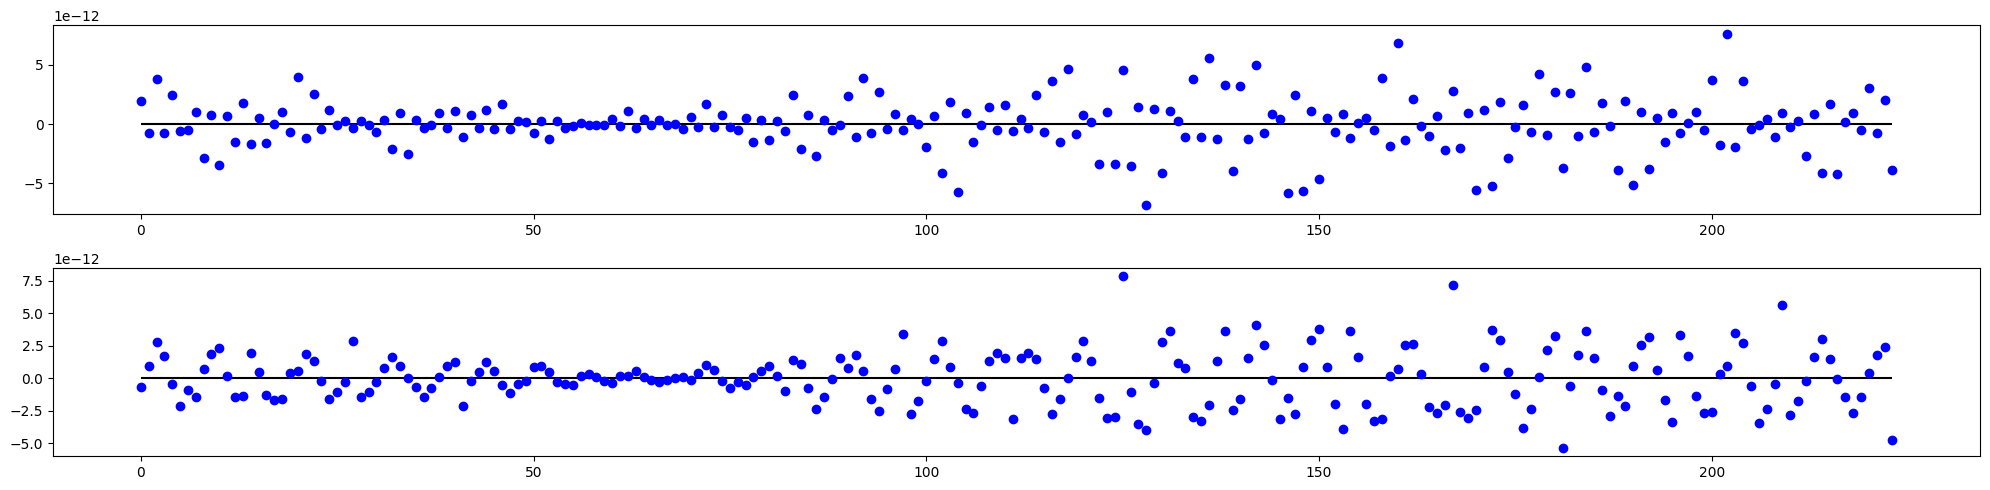

In [24]:
# Compare phase advance

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux - table.phase_x.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy - table.phase_y.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

## Twiss from amplitude & phase

In [25]:
# Set twiss

twiss = Twiss(model, table, limit=4)

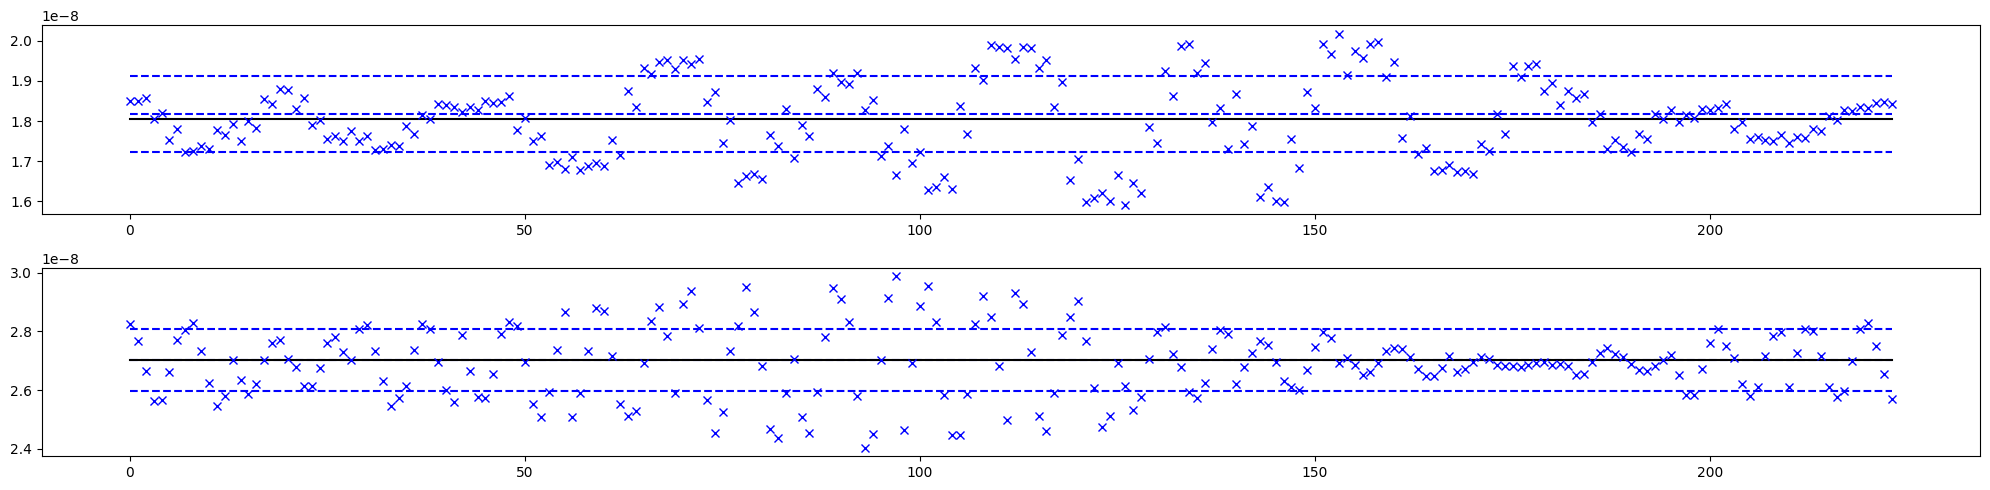

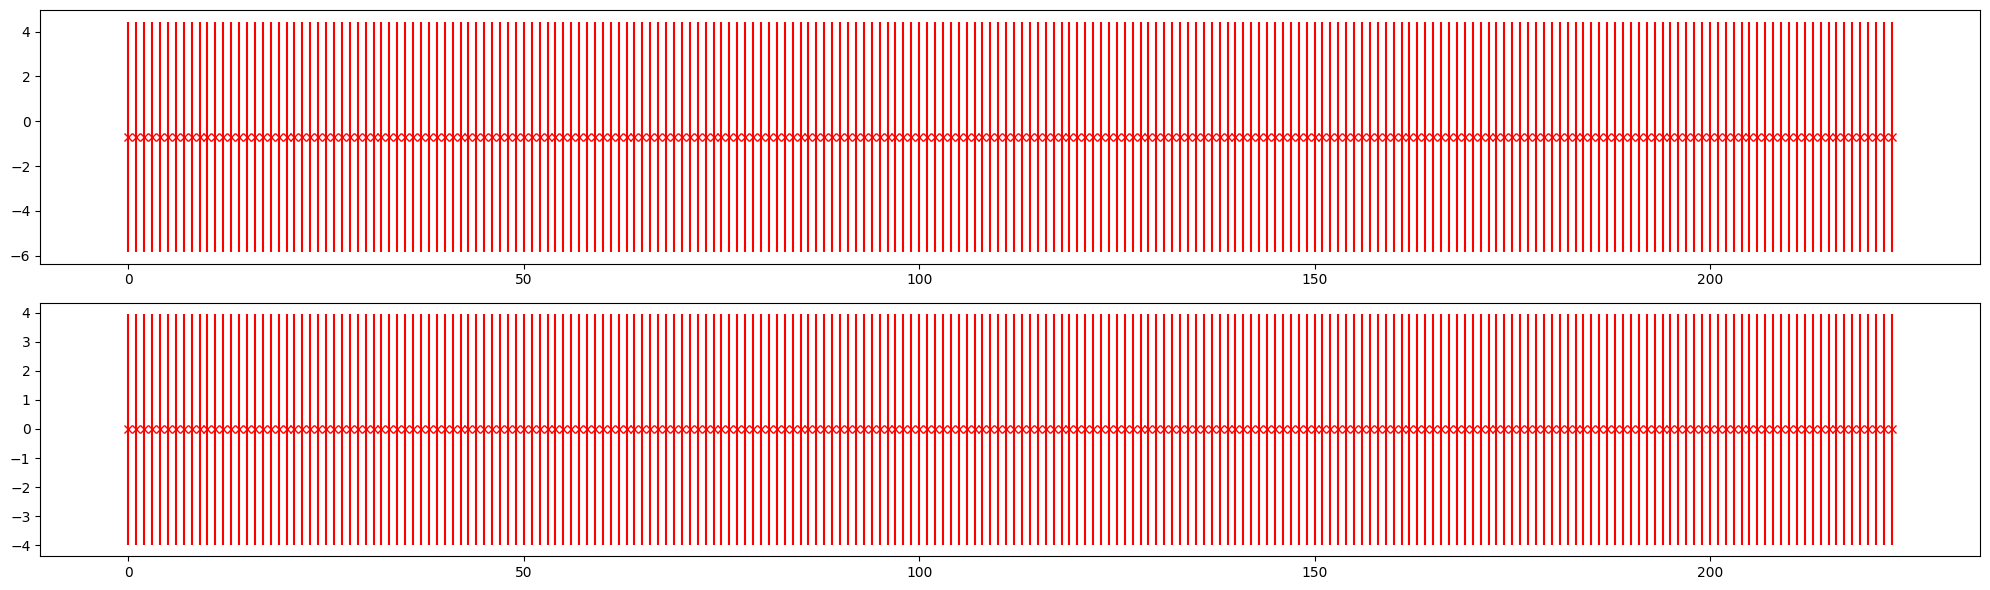

tensor(0.6953, dtype=torch.float64)
tensor(0.0140, dtype=torch.float64)



In [26]:
# Estimate twiss from amplitude (model beta functions are used to estimate invariants)
# Note, errors in invariants results in 'systematic' shift of estimated parameters

twiss.get_action()
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

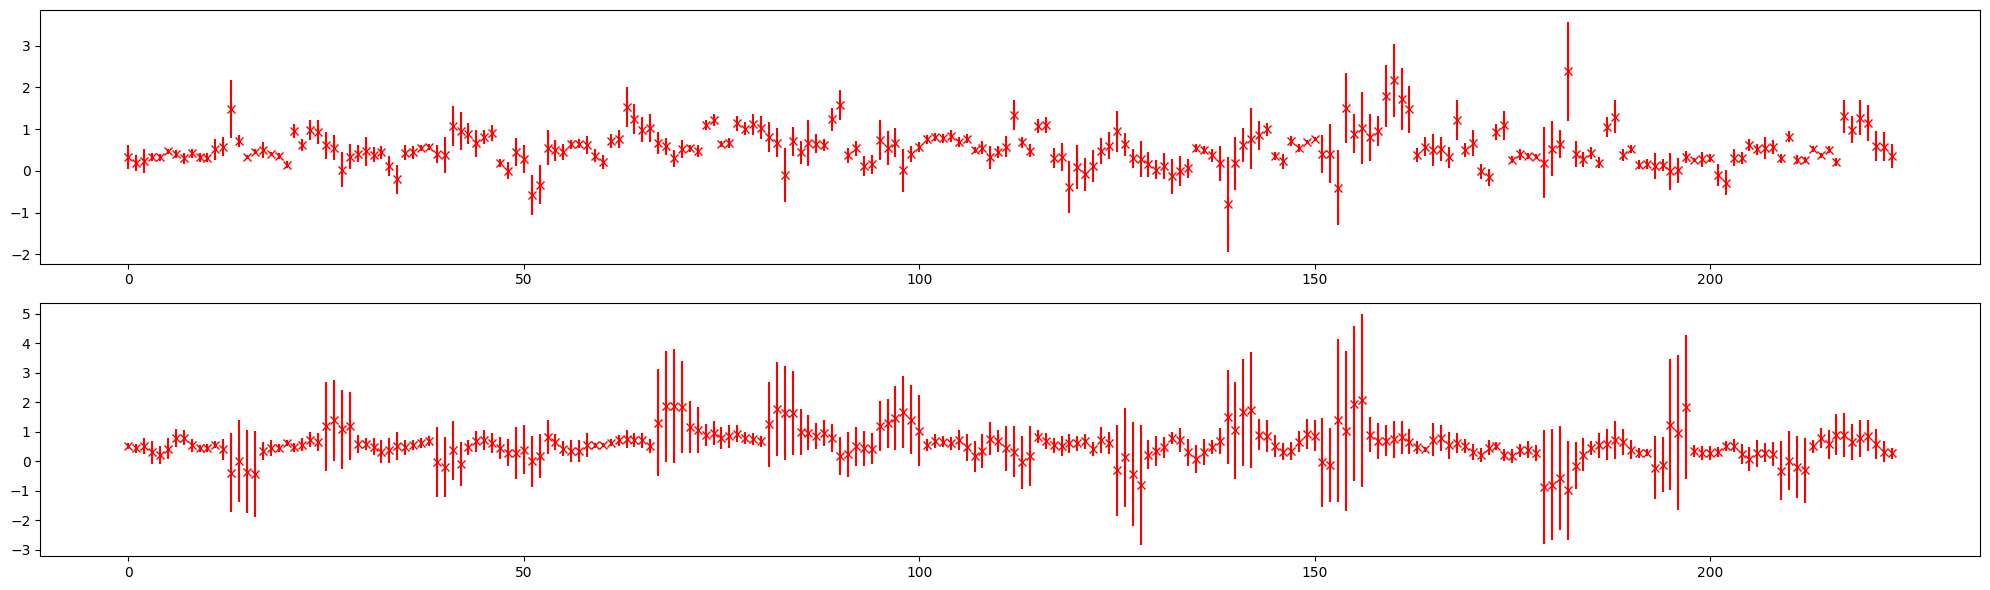

tensor(0.6992, dtype=torch.float64)
tensor(0.7615, dtype=torch.float64)



In [27]:
# Estimate twiss from phase

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by)/by).cpu().numpy(), yerr=100/by*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx)/bx)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by)/by)))
print()

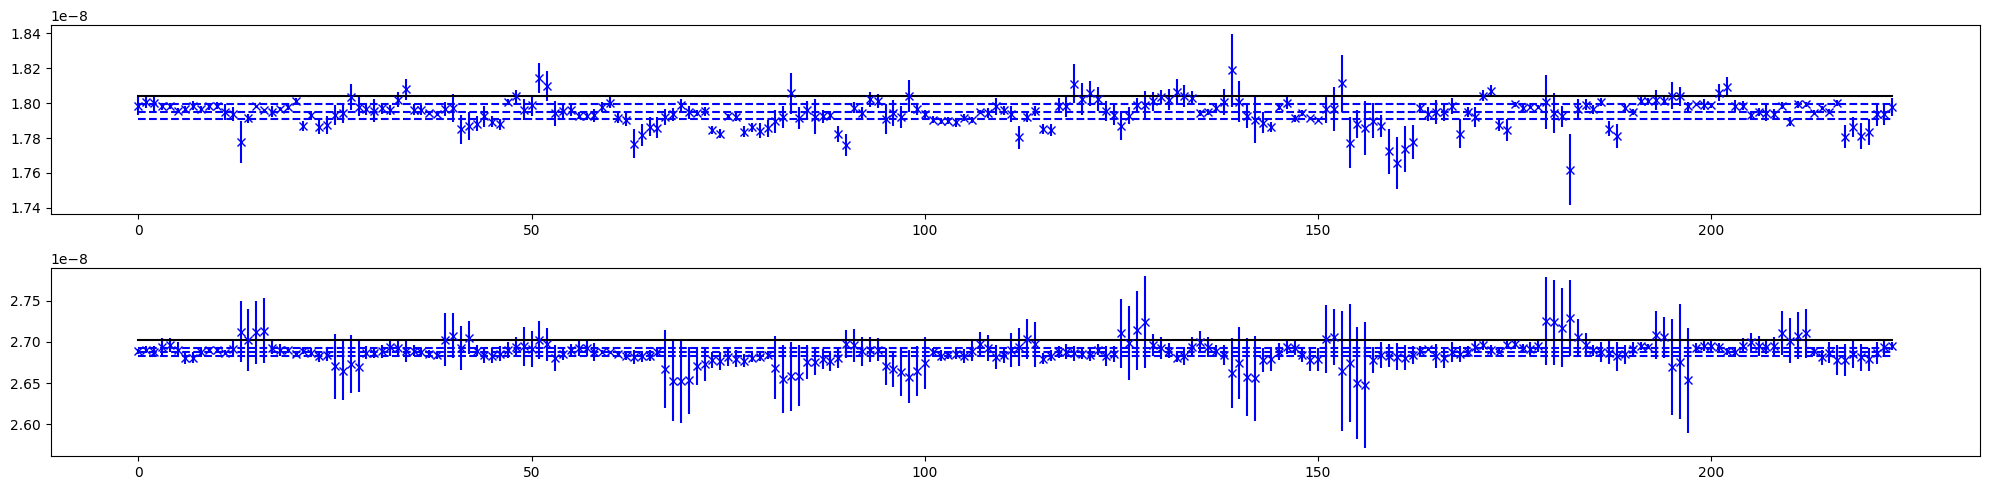

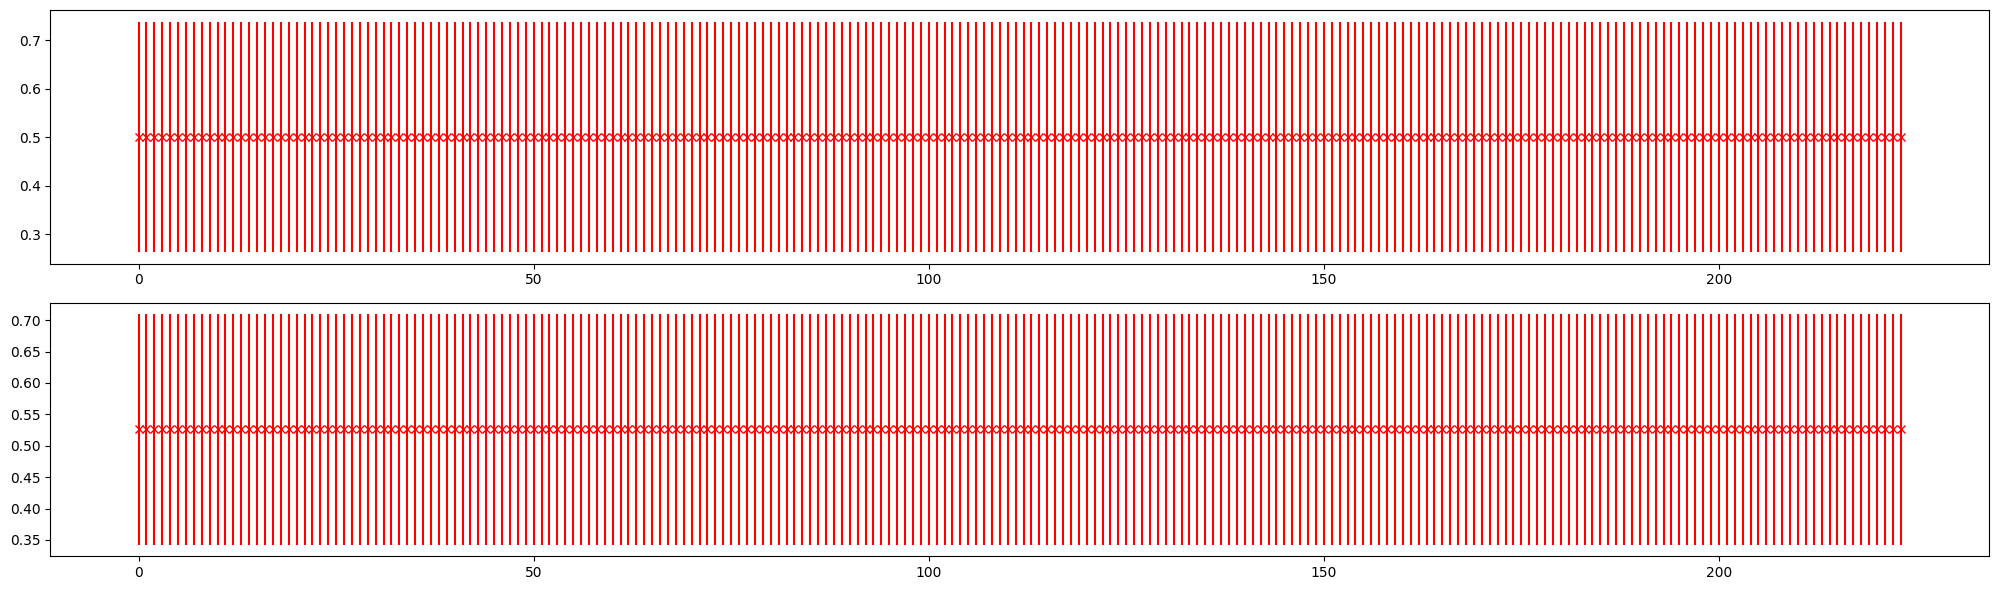

tensor(0.5006, dtype=torch.float64)
tensor(0.5261, dtype=torch.float64)



In [28]:
# Estimate twiss from amplitude (use twiss from phase for action estimation)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

In [29]:
# Note, invariant values, estimated using measured amplitudes and beta function assume zero coupling
# There is a systematic shift related to error of invariant estimation

## Twiss from invariant fit

In [30]:
# Here full set of coupled twiss parameters in computed along with coupled invariants
# These invariants are required for accurate computation of normalization matrix elements from amplitudes and phases
# If bpms have calibration errors, these invariants are still provide good approximation of true invariants, if fluctuations of calibrations have zero mean
# <gxx> = <gyy> = 1 and <gxy> = <gyx>

In [31]:
%%time

# Estimate twiss from invariant fit

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=None,          # -- ix invariant value
                                 iy=None,          # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 8min 10s, sys: 1min 38s, total: 9min 48s
Wall time: 11min 58s


In [32]:
# Process fitted invariants

ix_out = data[:, 0, 0]
iy_out = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(ix_out, iy_out, sigma_ix, sigma_iy)

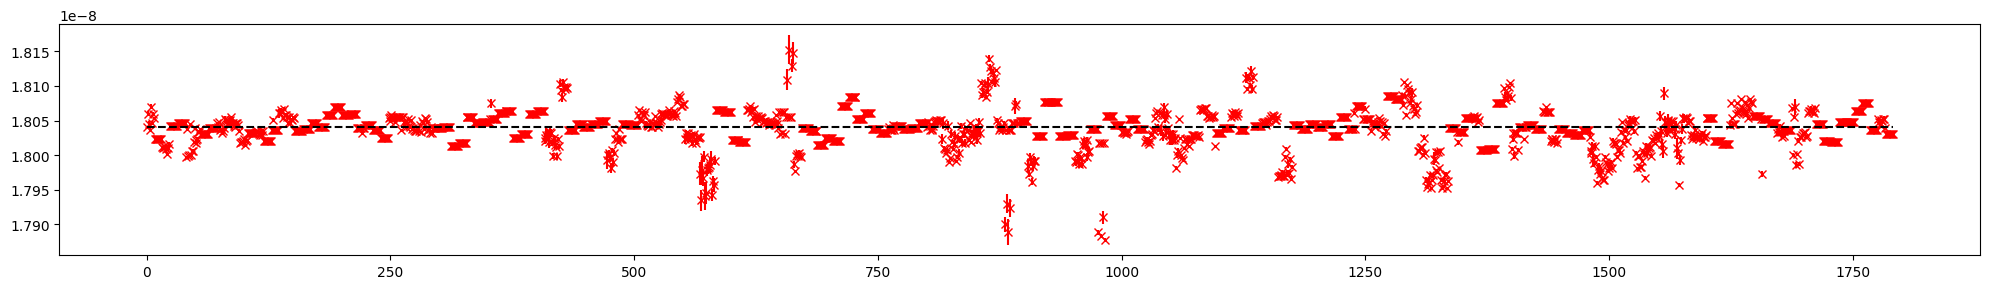

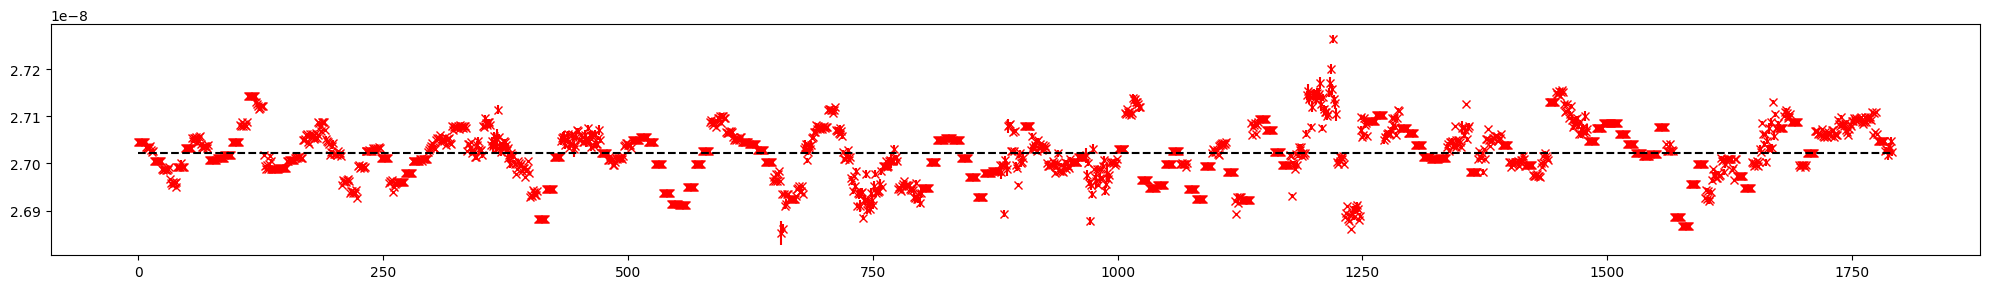

In [33]:
# Plot invariants for each sample in each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), ix_out.flatten().cpu().numpy(), yerr=sigma_ix.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(ix.mean(), 0, count*model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), iy_out.flatten().cpu().numpy(), yerr=sigma_iy.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(iy.mean(), 0, count*model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.tight_layout()
plt.show()

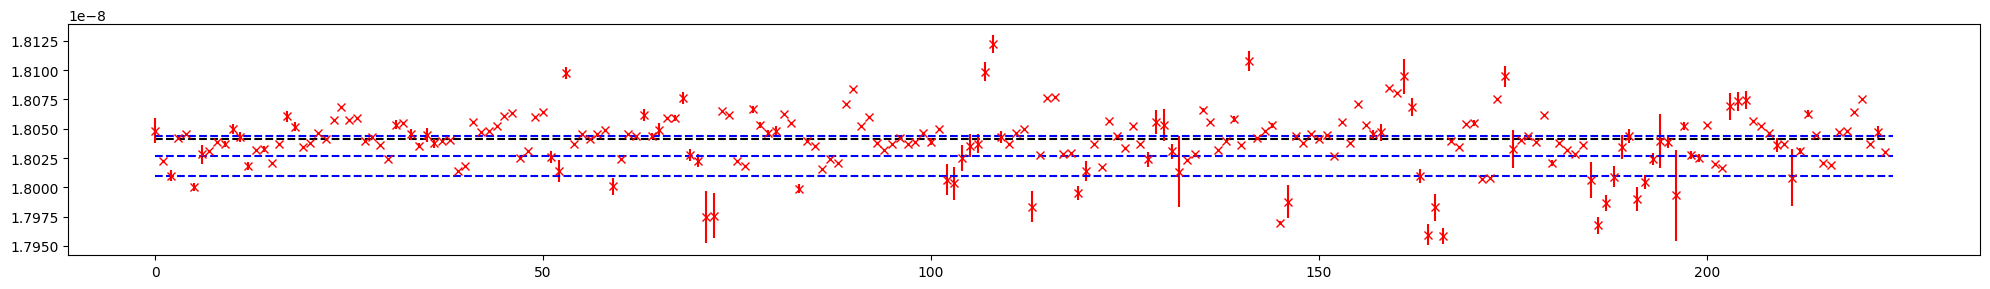

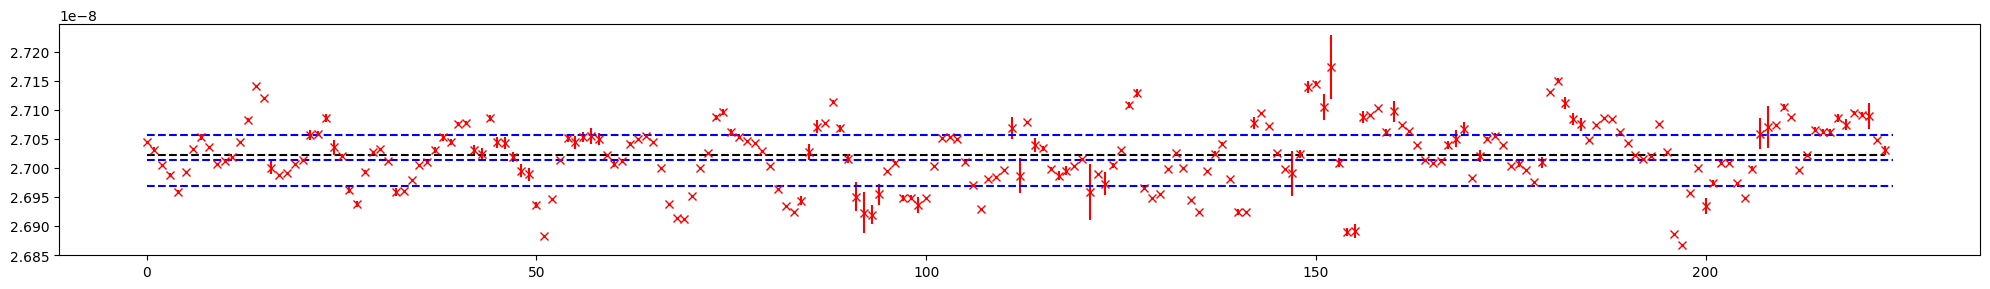

tensor(1.8041e-08, dtype=torch.float64)
tensor(1.7951e-08, dtype=torch.float64)
tensor(1.8027e-08, dtype=torch.float64)
tensor(1.8039e-08, dtype=torch.float64)

tensor(2.7023e-08, dtype=torch.float64)
tensor(2.6881e-08, dtype=torch.float64)
tensor(2.7013e-08, dtype=torch.float64)
tensor(2.7021e-08, dtype=torch.float64)



In [34]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(ix_out.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(iy_out.mean())
print()

In [35]:
# Process twiss

value_n11 = data[:, 0, 2]
error_n11 = data[:, 1, 2]

value_n33 = data[:, 0, 3]
error_n33 = data[:, 1, 3]

value_n21 = data[:, 0, 4]
error_n21 = data[:, 1, 4]

value_n43 = data[:, 0, 5]
error_n43 = data[:, 1, 5]

value_n13 = data[:, 0, 6]
error_n13 = data[:, 1, 6]

value_n31 = data[:, 0, 7]
error_n31 = data[:, 1, 7]

value_n14 = data[:, 0, 8]
error_n14 = data[:, 1, 8]

value_n41 = data[:, 0, 9]
error_n41 = data[:, 1, 9]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

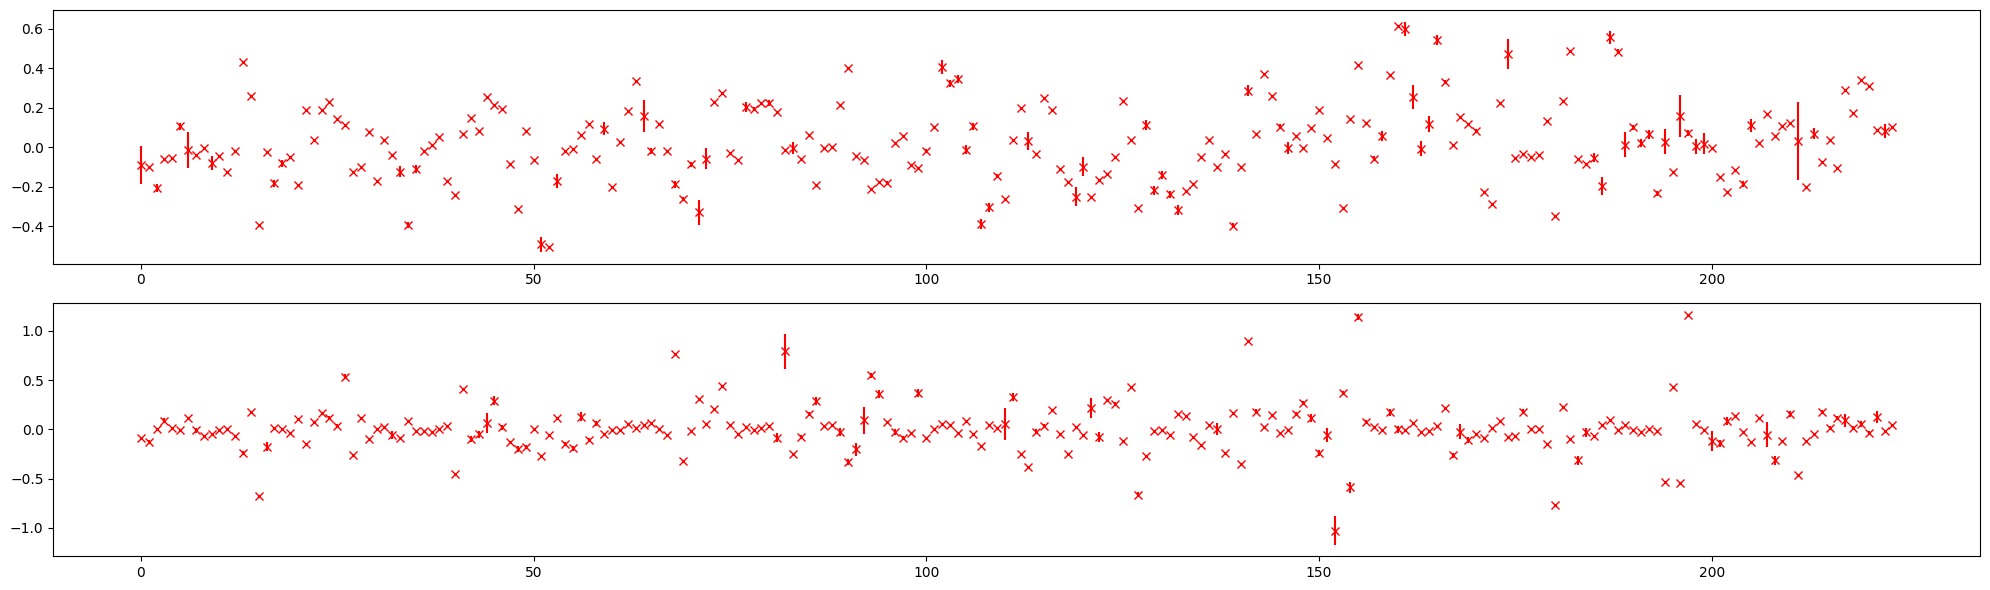

tensor(0.2014, dtype=torch.float64)
tensor(0.2475, dtype=torch.float64)



In [36]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

In [37]:
# Compare estimated normalization matrix elements

tensor(0.0029, dtype=torch.float64)

tensor(0.0022, dtype=torch.float64)

tensor(0.0015, dtype=torch.float64)

tensor(0.0026, dtype=torch.float64)

tensor(0.0021, dtype=torch.float64)

tensor(0.0024, dtype=torch.float64)

tensor(0.0012, dtype=torch.float64)

tensor(0.0021, dtype=torch.float64)



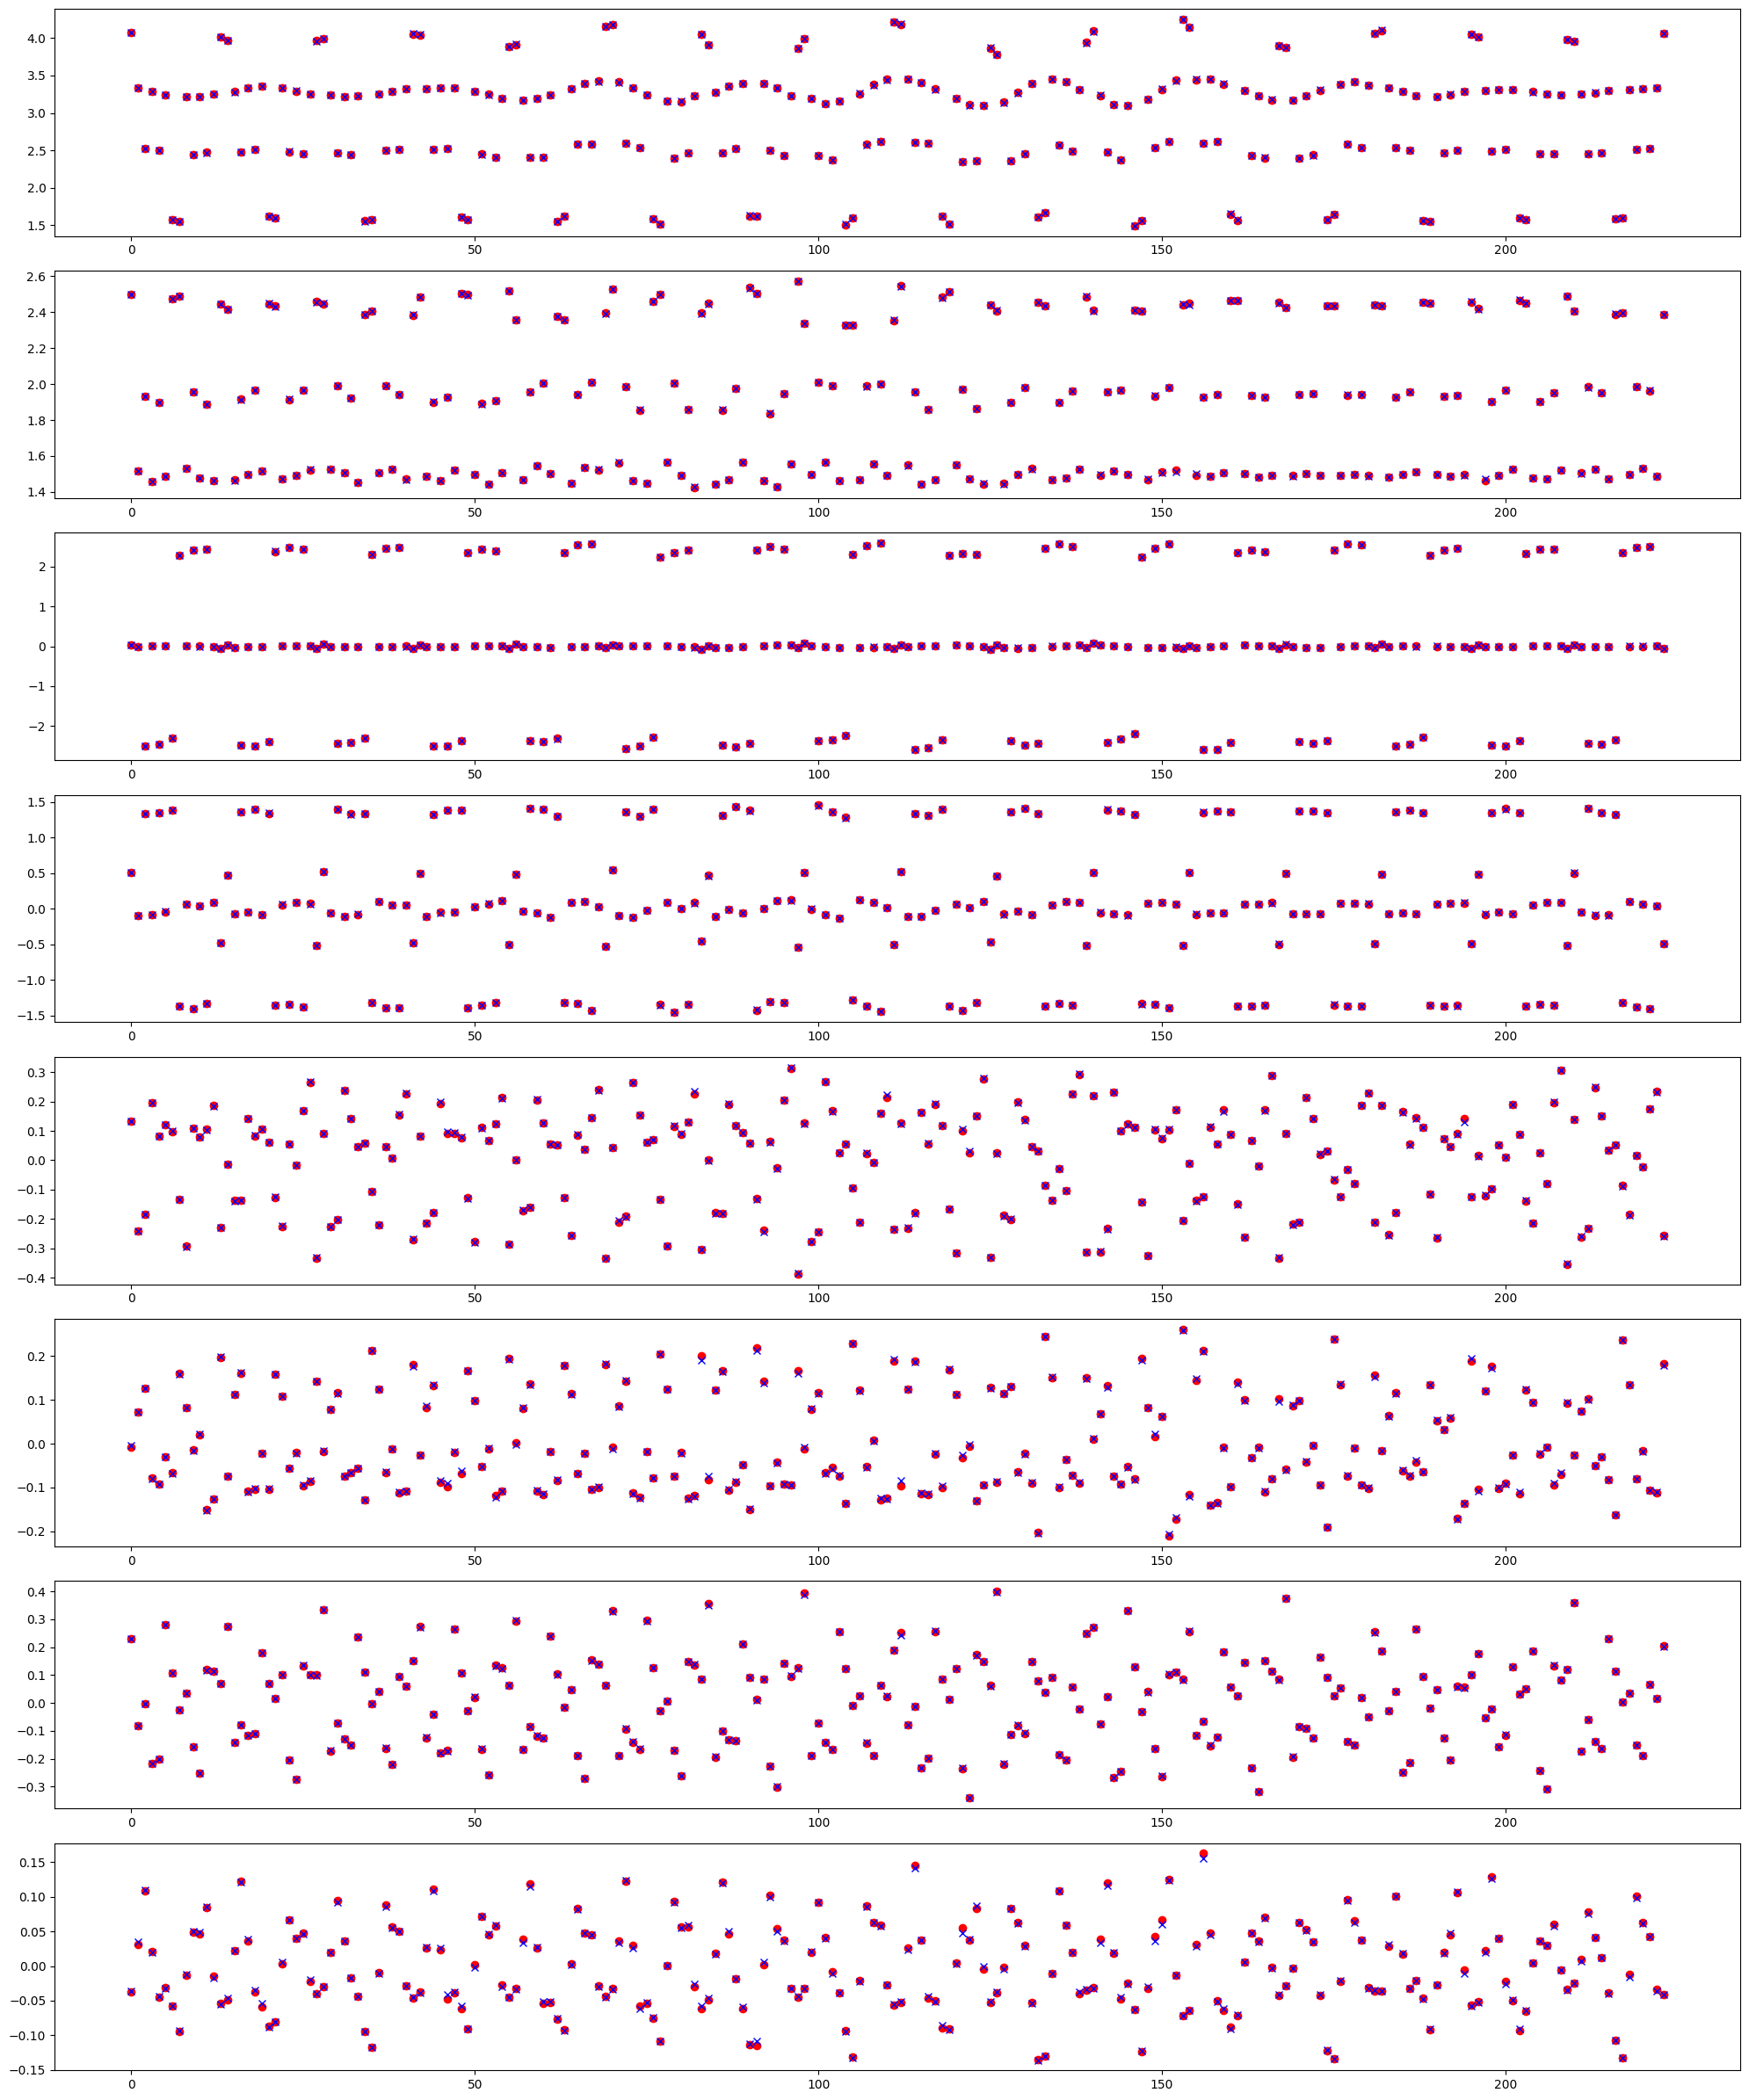

In [38]:
plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), n11.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n11.cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), n33.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n33.cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), n21.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n21.cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), n43.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n43.cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), n13.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n13.cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), n31.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n31.cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), n14.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n14.cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), n41.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n41.cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print()

plt.tight_layout()
plt.show()

In [39]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, 2, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 256])


In [40]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

BAG_IX = []
BAG_IY = []

for location in range(model.monitor_count):
    
    BAG_IX_MONITOR = []
    BAG_IY_MONITOR = []
    
    for _ in range(128):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        BAG_IX_MONITOR.append(IX)
        BAG_IY_MONITOR.append(IY)
        
    BAG_IX.append(BAG_IX_MONITOR)
    BAG_IY.append(BAG_IY_MONITOR)

BAG_IX = torch.stack([torch.stack(IX) for IX in BAG_IX]).reshape(model.monitor_count, -1)
BAG_IY = torch.stack([torch.stack(IY) for IY in BAG_IY]).reshape(model.monitor_count, -1)

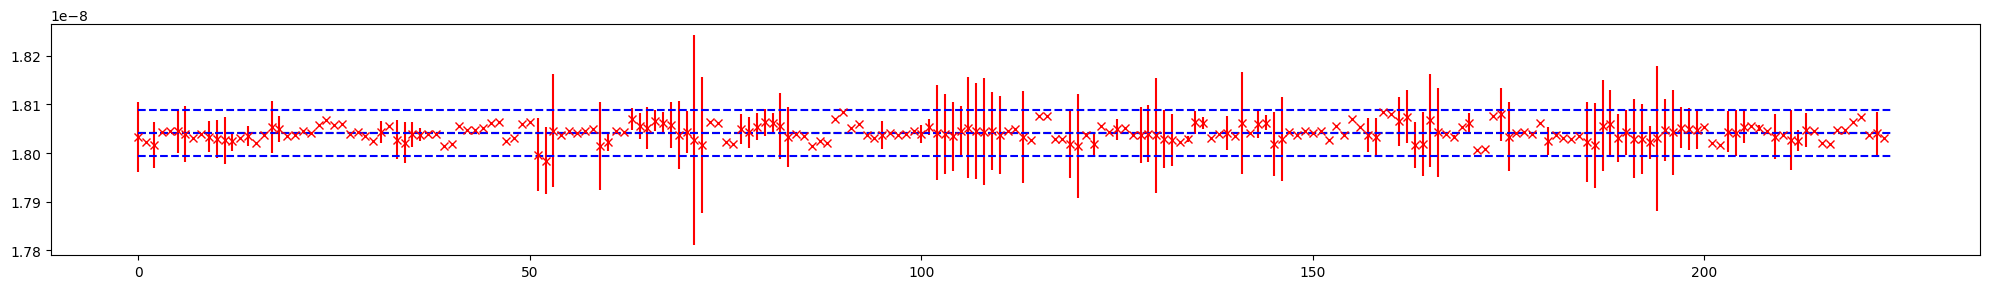

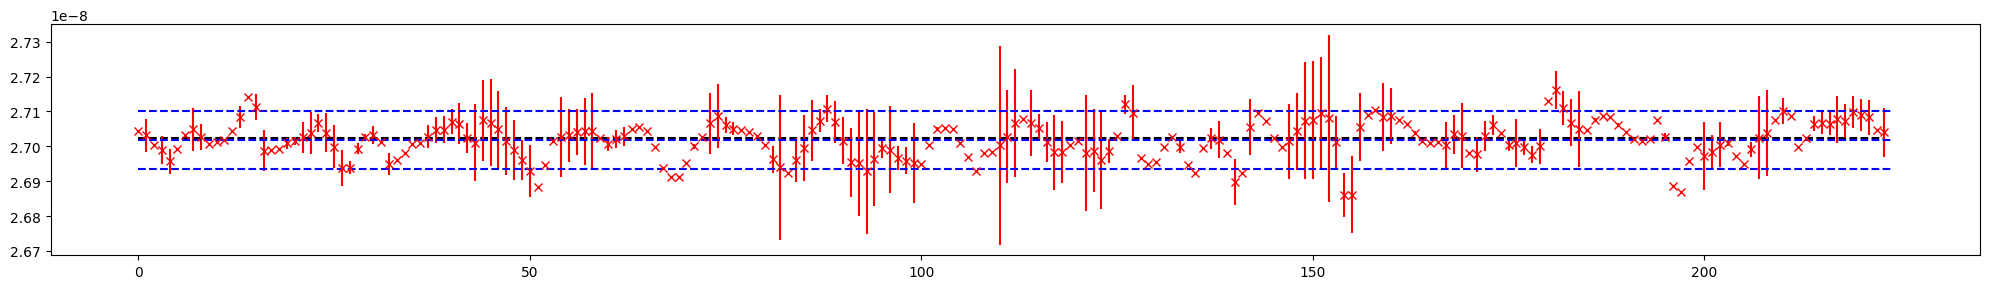

tensor(1.8041e-08, dtype=torch.float64)
tensor(1.7951e-08, dtype=torch.float64)
tensor(1.8027e-08, dtype=torch.float64)
tensor(1.8039e-08, dtype=torch.float64)
tensor(1.8042e-08, dtype=torch.float64)

tensor(2.7023e-08, dtype=torch.float64)
tensor(2.6881e-08, dtype=torch.float64)
tensor(2.7013e-08, dtype=torch.float64)
tensor(2.7021e-08, dtype=torch.float64)
tensor(2.7018e-08, dtype=torch.float64)



In [41]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IX.mean(-1).flatten().cpu().numpy(), yerr=BAG_IX.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')

plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IX.mean() - BAG_IX.std(), BAG_IX.mean(), BAG_IX.mean() + BAG_IX.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IY.mean(-1).flatten().cpu().numpy(), yerr=BAG_IY.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IY.mean() - BAG_IY.std(), BAG_IY.mean(), BAG_IY.mean() + BAG_IY.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(ix_out.mean())
print(BAG_IX.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(iy_out.mean())
print(BAG_IY.mean())
print()

In [42]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=BAG_IX.mean(), # -- ix invariant value
                                 iy=BAG_IY.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 8min 16s, sys: 1min 19s, total: 9min 35s
Wall time: 11min 48s


In [43]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

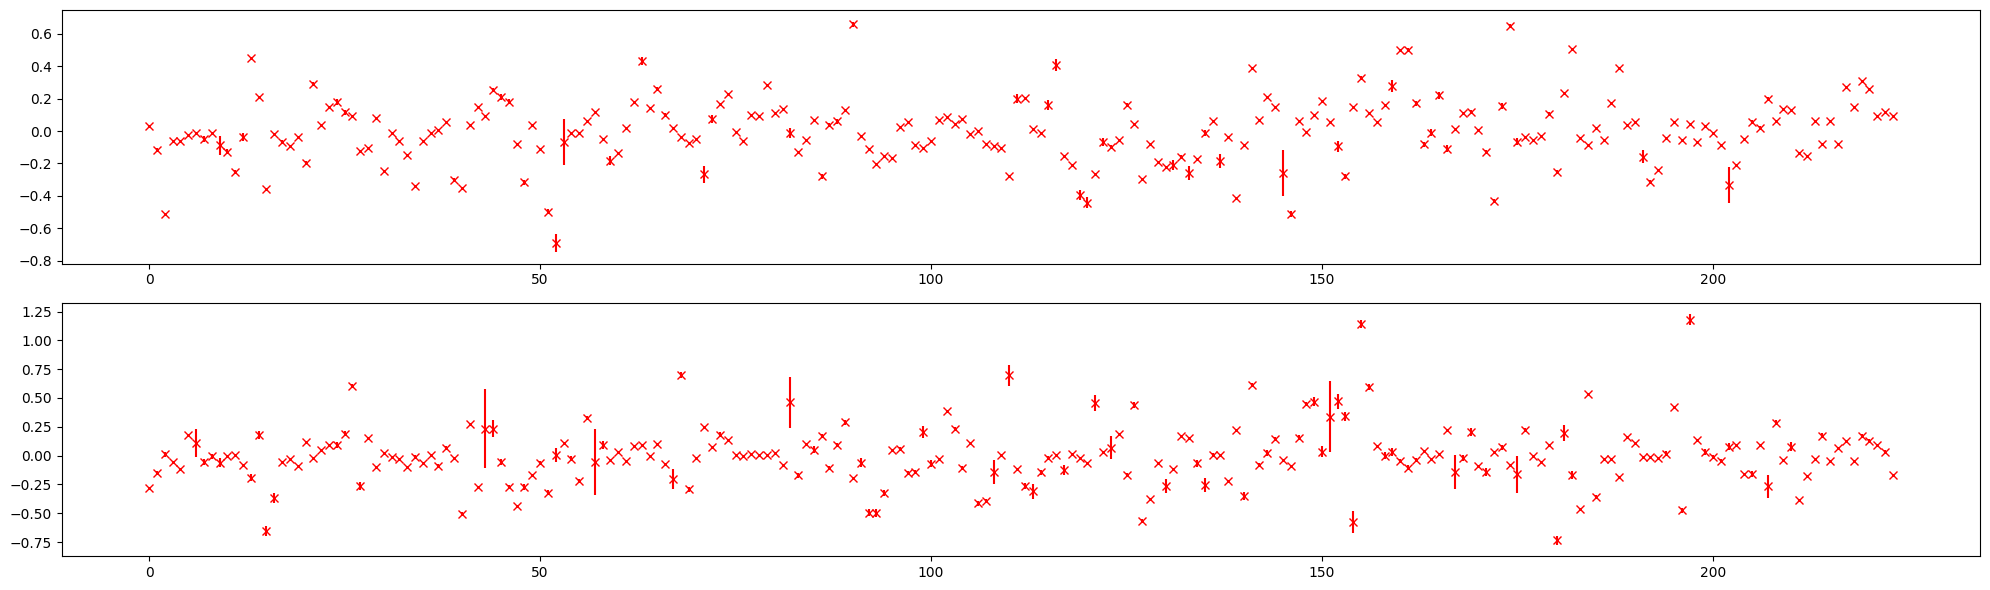

tensor(0.1995, dtype=torch.float64)
tensor(0.2530, dtype=torch.float64)



In [44]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

tensor(0.0028, dtype=torch.float64)

tensor(0.0023, dtype=torch.float64)

tensor(0.0015, dtype=torch.float64)

tensor(0.0029, dtype=torch.float64)

tensor(0.0022, dtype=torch.float64)

tensor(0.0024, dtype=torch.float64)

tensor(0.0018, dtype=torch.float64)

tensor(0.0021, dtype=torch.float64)



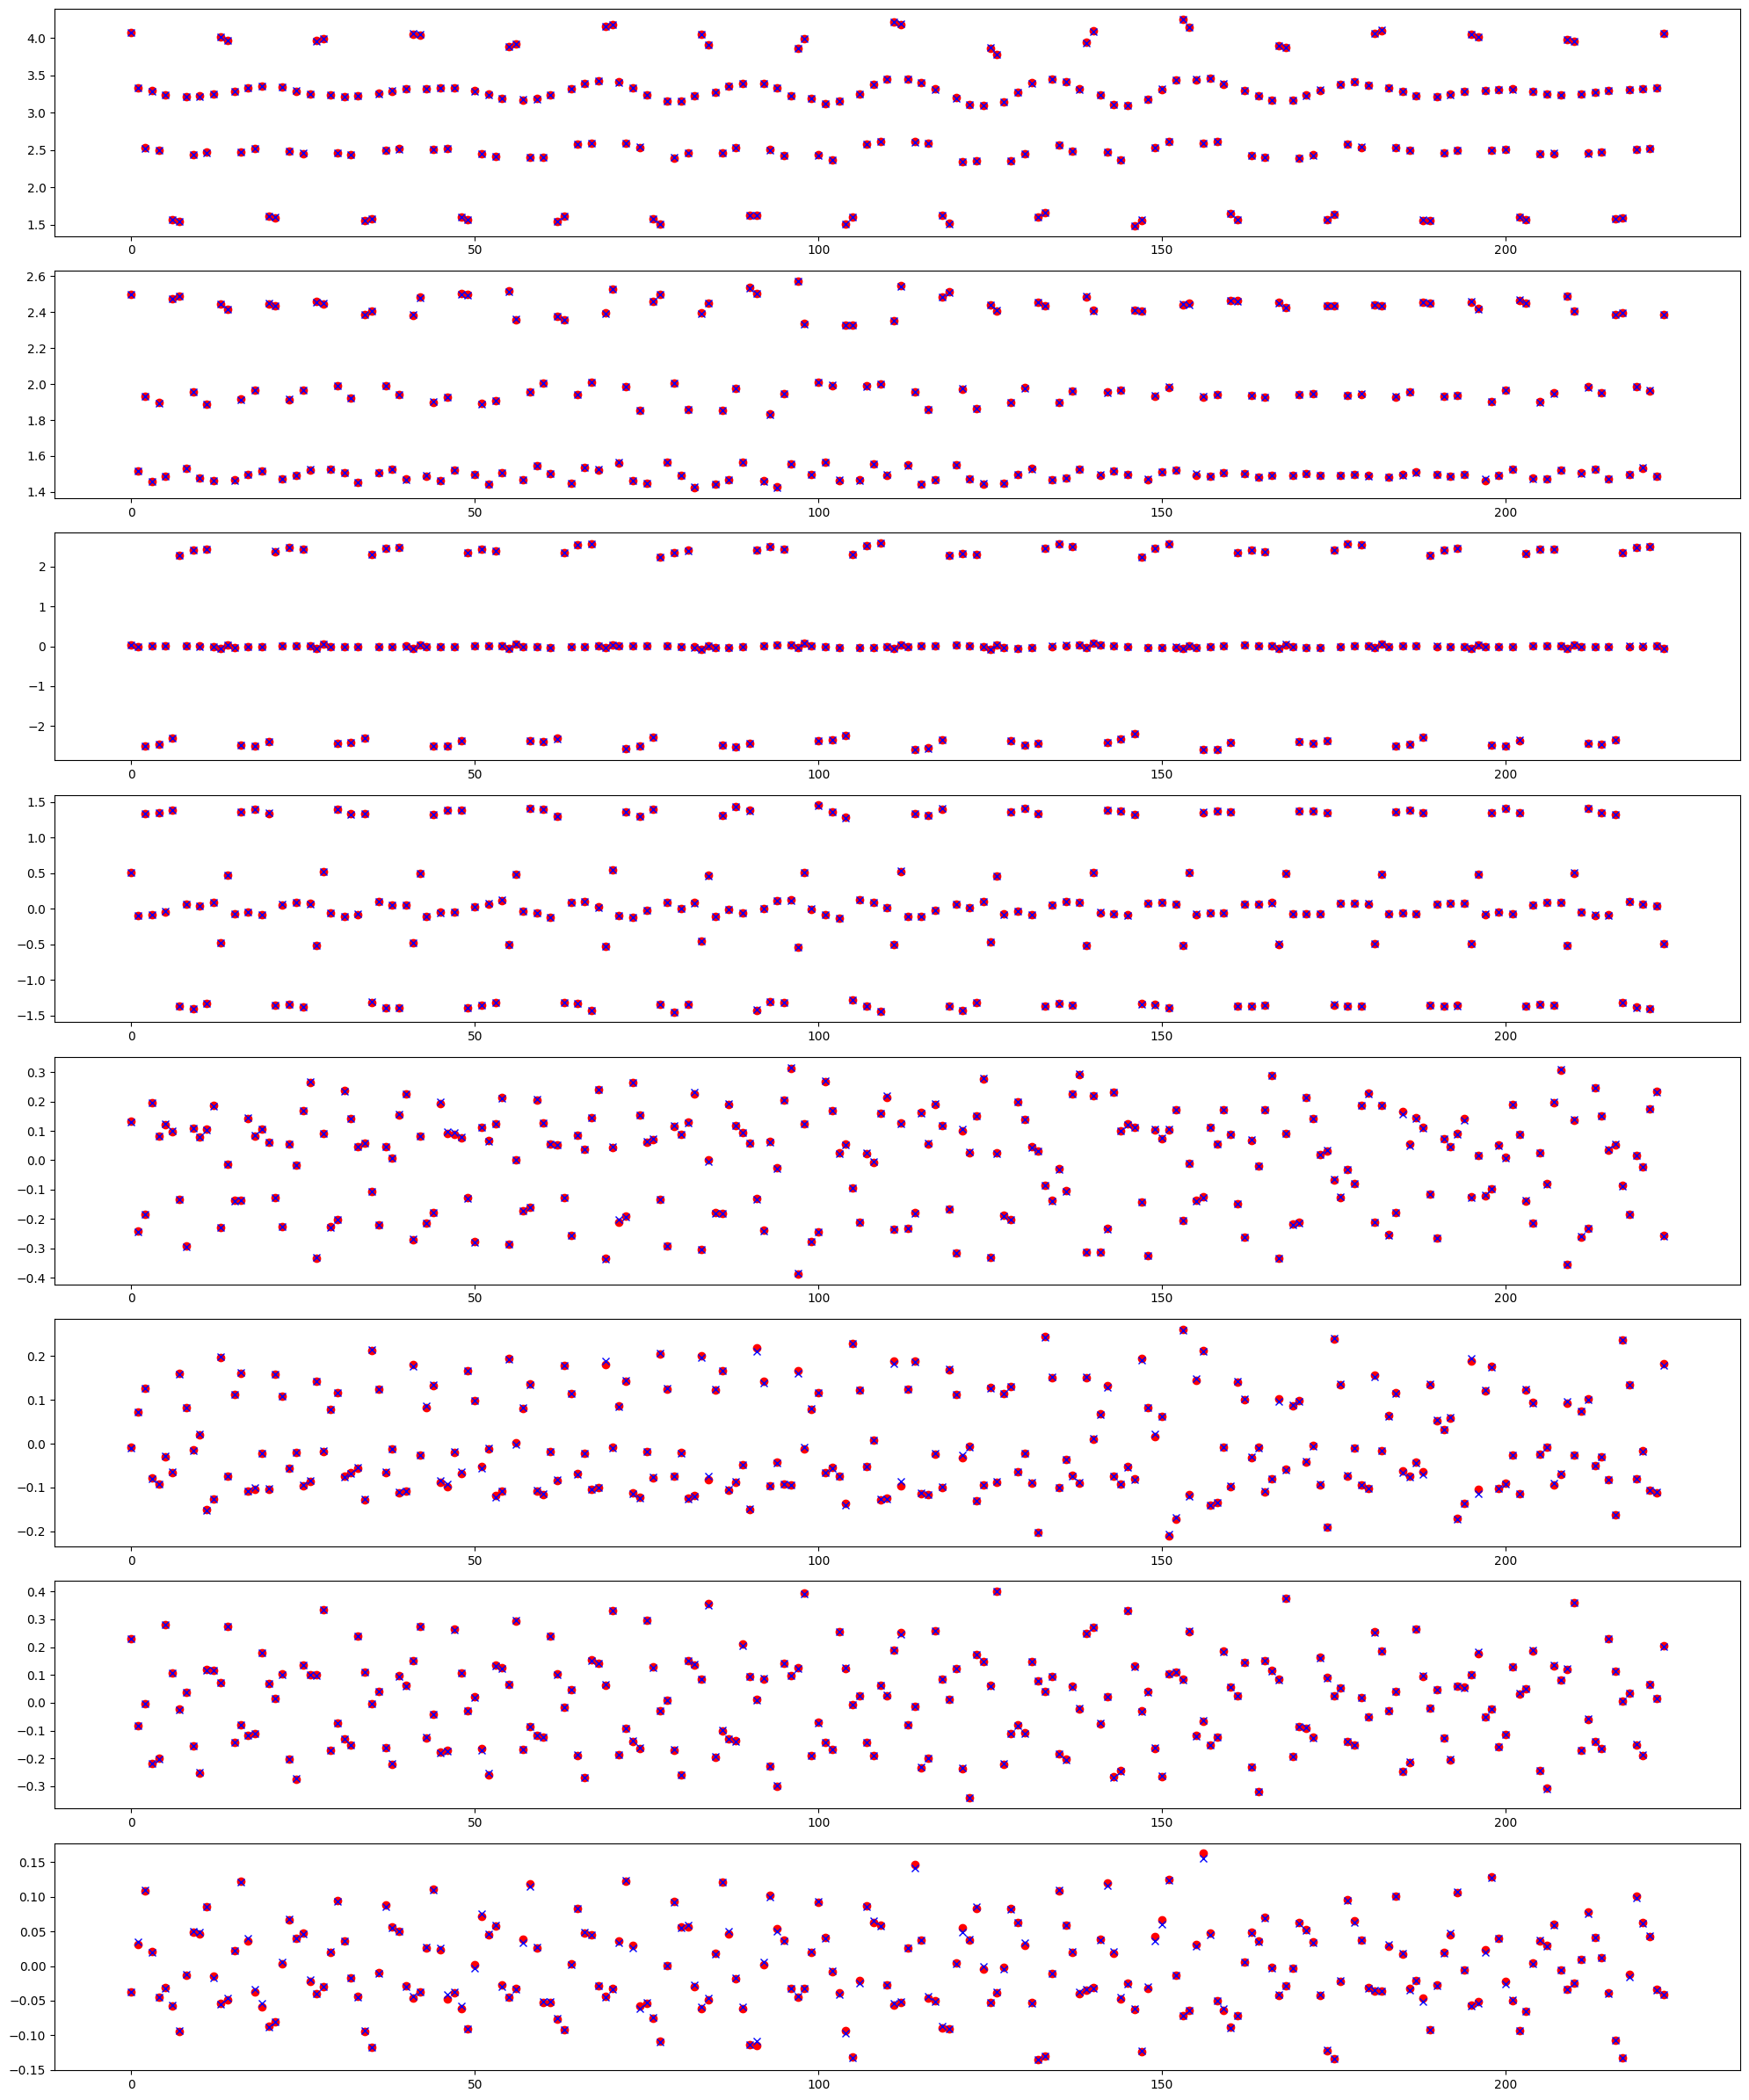

In [45]:
plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), n11.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n11.cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), n33.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n33.cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), n21.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n21.cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), n43.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n43.cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), n13.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n13.cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), n31.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n31.cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), n14.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n14.cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), n41.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n41.cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print()

plt.tight_layout()
plt.show()

In [46]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, 2, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 256])


In [47]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

BAG_IX = []
BAG_IY = []

for location in range(model.monitor_count):
    
    BAG_IX_MONITOR = []
    BAG_IY_MONITOR = []
    
    for _ in range(128):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        BAG_IX_MONITOR.append(IX)
        BAG_IY_MONITOR.append(IY)
        
    BAG_IX.append(BAG_IX_MONITOR)
    BAG_IY.append(BAG_IY_MONITOR)

BAG_IX = torch.stack([torch.stack(IX) for IX in BAG_IX]).reshape(model.monitor_count, -1)
BAG_IY = torch.stack([torch.stack(IY) for IY in BAG_IY]).reshape(model.monitor_count, -1)

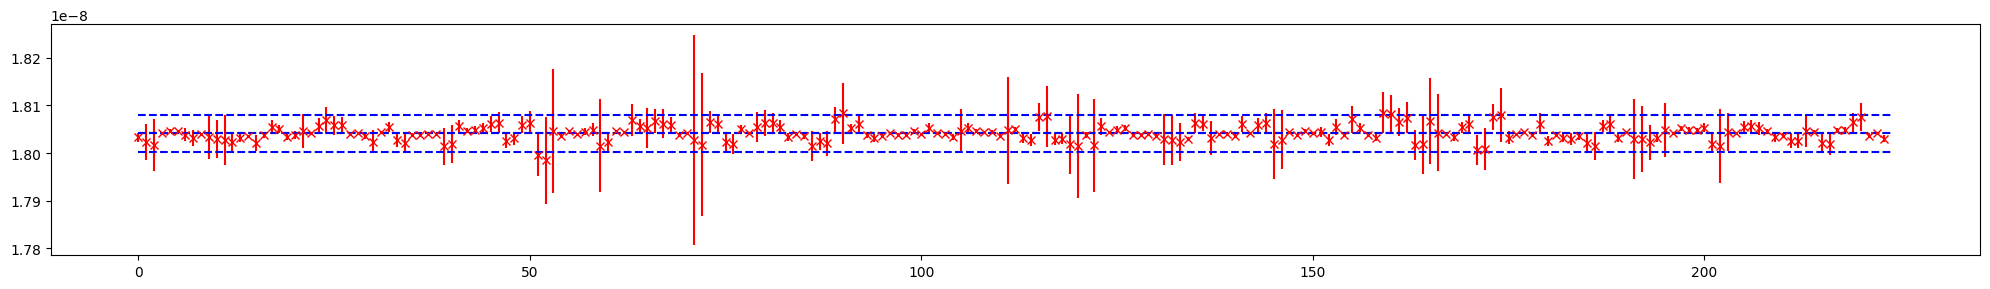

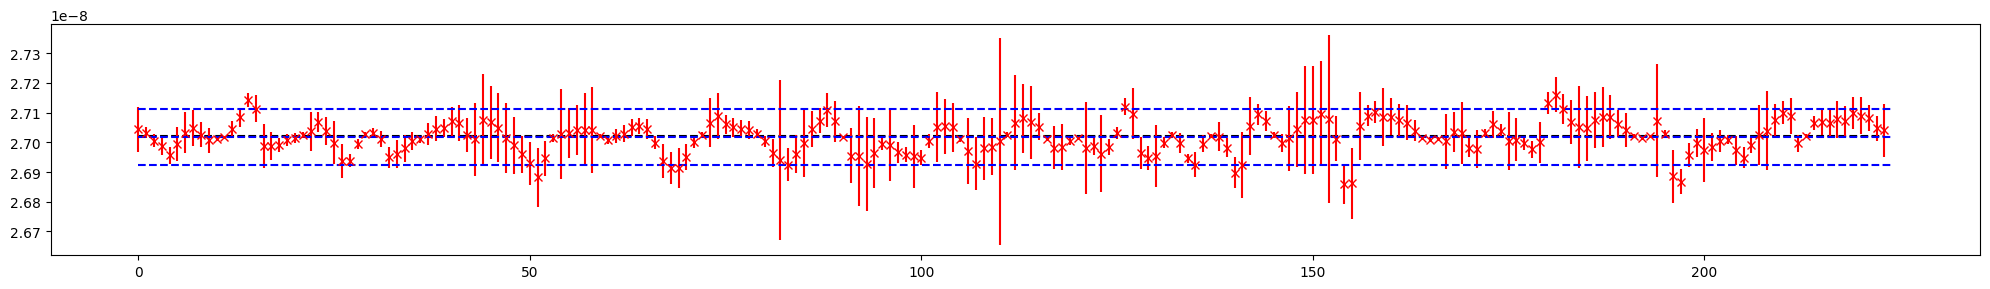

tensor(1.8041e-08, dtype=torch.float64)
tensor(1.7951e-08, dtype=torch.float64)
tensor(1.8027e-08, dtype=torch.float64)
tensor(1.8042e-08, dtype=torch.float64)

tensor(2.7023e-08, dtype=torch.float64)
tensor(2.6881e-08, dtype=torch.float64)
tensor(2.7013e-08, dtype=torch.float64)
tensor(2.7018e-08, dtype=torch.float64)



In [48]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IX.mean(-1).flatten().cpu().numpy(), yerr=BAG_IX.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')

plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IX.mean() - BAG_IX.std(), BAG_IX.mean(), BAG_IX.mean() + BAG_IX.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IY.mean(-1).flatten().cpu().numpy(), yerr=BAG_IY.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IY.mean() - BAG_IY.std(), BAG_IY.mean(), BAG_IY.mean() + BAG_IY.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(BAG_IX.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(BAG_IY.mean())
print()

In [49]:
# Set all normalization matrix elements

value_normal = torch.stack([parametric_normal(w11, w33, w21, w43, w13, w31, w14, w41) for w11, w33, w21, w43, w13, w31, w14, w41 in zip(value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41)])

value_n11 = value_normal[:, 0, 0]
value_n12 = value_normal[:, 0, 1]
value_n13 = value_normal[:, 0, 2]
value_n14 = value_normal[:, 0, 3]

value_n21 = value_normal[:, 1, 0]
value_n22 = value_normal[:, 1, 1]
value_n23 = value_normal[:, 1, 2]
value_n24 = value_normal[:, 1, 3]

value_n31 = value_normal[:, 2, 0]
value_n32 = value_normal[:, 2, 1]
value_n33 = value_normal[:, 2, 2]
value_n34 = value_normal[:, 2, 3]

value_n41 = value_normal[:, 3, 0]
value_n42 = value_normal[:, 3, 1]
value_n43 = value_normal[:, 3, 2]
value_n44 = value_normal[:, 3, 3]

## Normalization matrix elements (coordinates)

In [50]:
# Check amplitudes (using exact values for invariants and normalization matrix elements)

print(root_mean_square(axx**2 - 2*ix*n11**2))
print(root_mean_square(axy**2 - 2*iy*(n13**2 + n14**2)))
print(root_mean_square(ayx**2 - 2*ix*(n31**2 + n32**2)))
print(root_mean_square(ayy**2 - 2*iy*n33**2))

tensor(2.5465e-18, dtype=torch.float64)
tensor(2.5411e-18, dtype=torch.float64)
tensor(9.8576e-19, dtype=torch.float64)
tensor(1.1779e-18, dtype=torch.float64)


In [51]:
# Check phases (using exact values for invariants and normalization matrix elements)

print(root_mean_square(fxy - torch.atan2((fyy.sin() * n13 + fyy.cos() * n14), (fyy.cos() * n13 - fyy.sin() * n14))))
print(root_mean_square(fyx - torch.atan2((fxx.sin() * n31 + fxx.cos() * n32), (fxx.cos() * n31 - fxx.sin() * n32))))

tensor(1.8117e-09, dtype=torch.float64)
tensor(2.7098e-09, dtype=torch.float64)


In [52]:
# Check normalization matrix elements (using exact values for invariants and normalization matrix elements)

print(root_mean_square(n11**2 - axx**2/(2*ix)))
print(root_mean_square(n33**2 - ayy**2/(2*iy)))
print(root_mean_square((n13**2 + n14**2) - axy**2/(2*iy)))
print(root_mean_square((n31**2 + n32**2) - ayx**2/(2*ix)))
print(root_mean_square(n13 - axy/ayy*(fxy - fyy).cos()*n33))
print(root_mean_square(n14 - axy/ayy*(fxy - fyy).sin()*n33))
print(root_mean_square(n31 - ayx/axx*(fyx - fxx).cos()*n11))
print(root_mean_square(n32 - ayx/axx*(fyx - fxx).sin()*n11))

tensor(7.0574e-11, dtype=torch.float64)
tensor(2.1794e-11, dtype=torch.float64)
tensor(4.7018e-11, dtype=torch.float64)
tensor(2.7320e-11, dtype=torch.float64)
tensor(2.8308e-10, dtype=torch.float64)
tensor(2.9109e-10, dtype=torch.float64)
tensor(2.6572e-10, dtype=torch.float64)
tensor(2.8627e-10, dtype=torch.float64)


In [53]:
# To compute  estimations of n11 and n33 from experimental data, approximation of invariants (ix and iy) are required
# As it can be see from the previous subsection, coupled invariants can be accuratly approximated

ix_fit = BAG_IX.mean()
iy_fit = BAG_IY.mean()

print(ix.mean())
print(ix_fit)
print()

print(iy.mean())
print(iy_fit.mean())
print()

tensor(1.8041e-08, dtype=torch.float64)
tensor(1.8042e-08, dtype=torch.float64)

tensor(2.7023e-08, dtype=torch.float64)
tensor(2.7018e-08, dtype=torch.float64)



tensor(0.0028, dtype=torch.float64)
tensor(3.6788e-05, dtype=torch.float64)

tensor(0.0023, dtype=torch.float64)
tensor(0.0002, dtype=torch.float64)

tensor(0.0022, dtype=torch.float64)
tensor(1.5571e-05, dtype=torch.float64)

tensor(0.0018, dtype=torch.float64)
tensor(1.5029e-05, dtype=torch.float64)

tensor(0.0024, dtype=torch.float64)
tensor(1.3861e-06, dtype=torch.float64)

tensor(0.0011, dtype=torch.float64)
tensor(1.2831e-06, dtype=torch.float64)



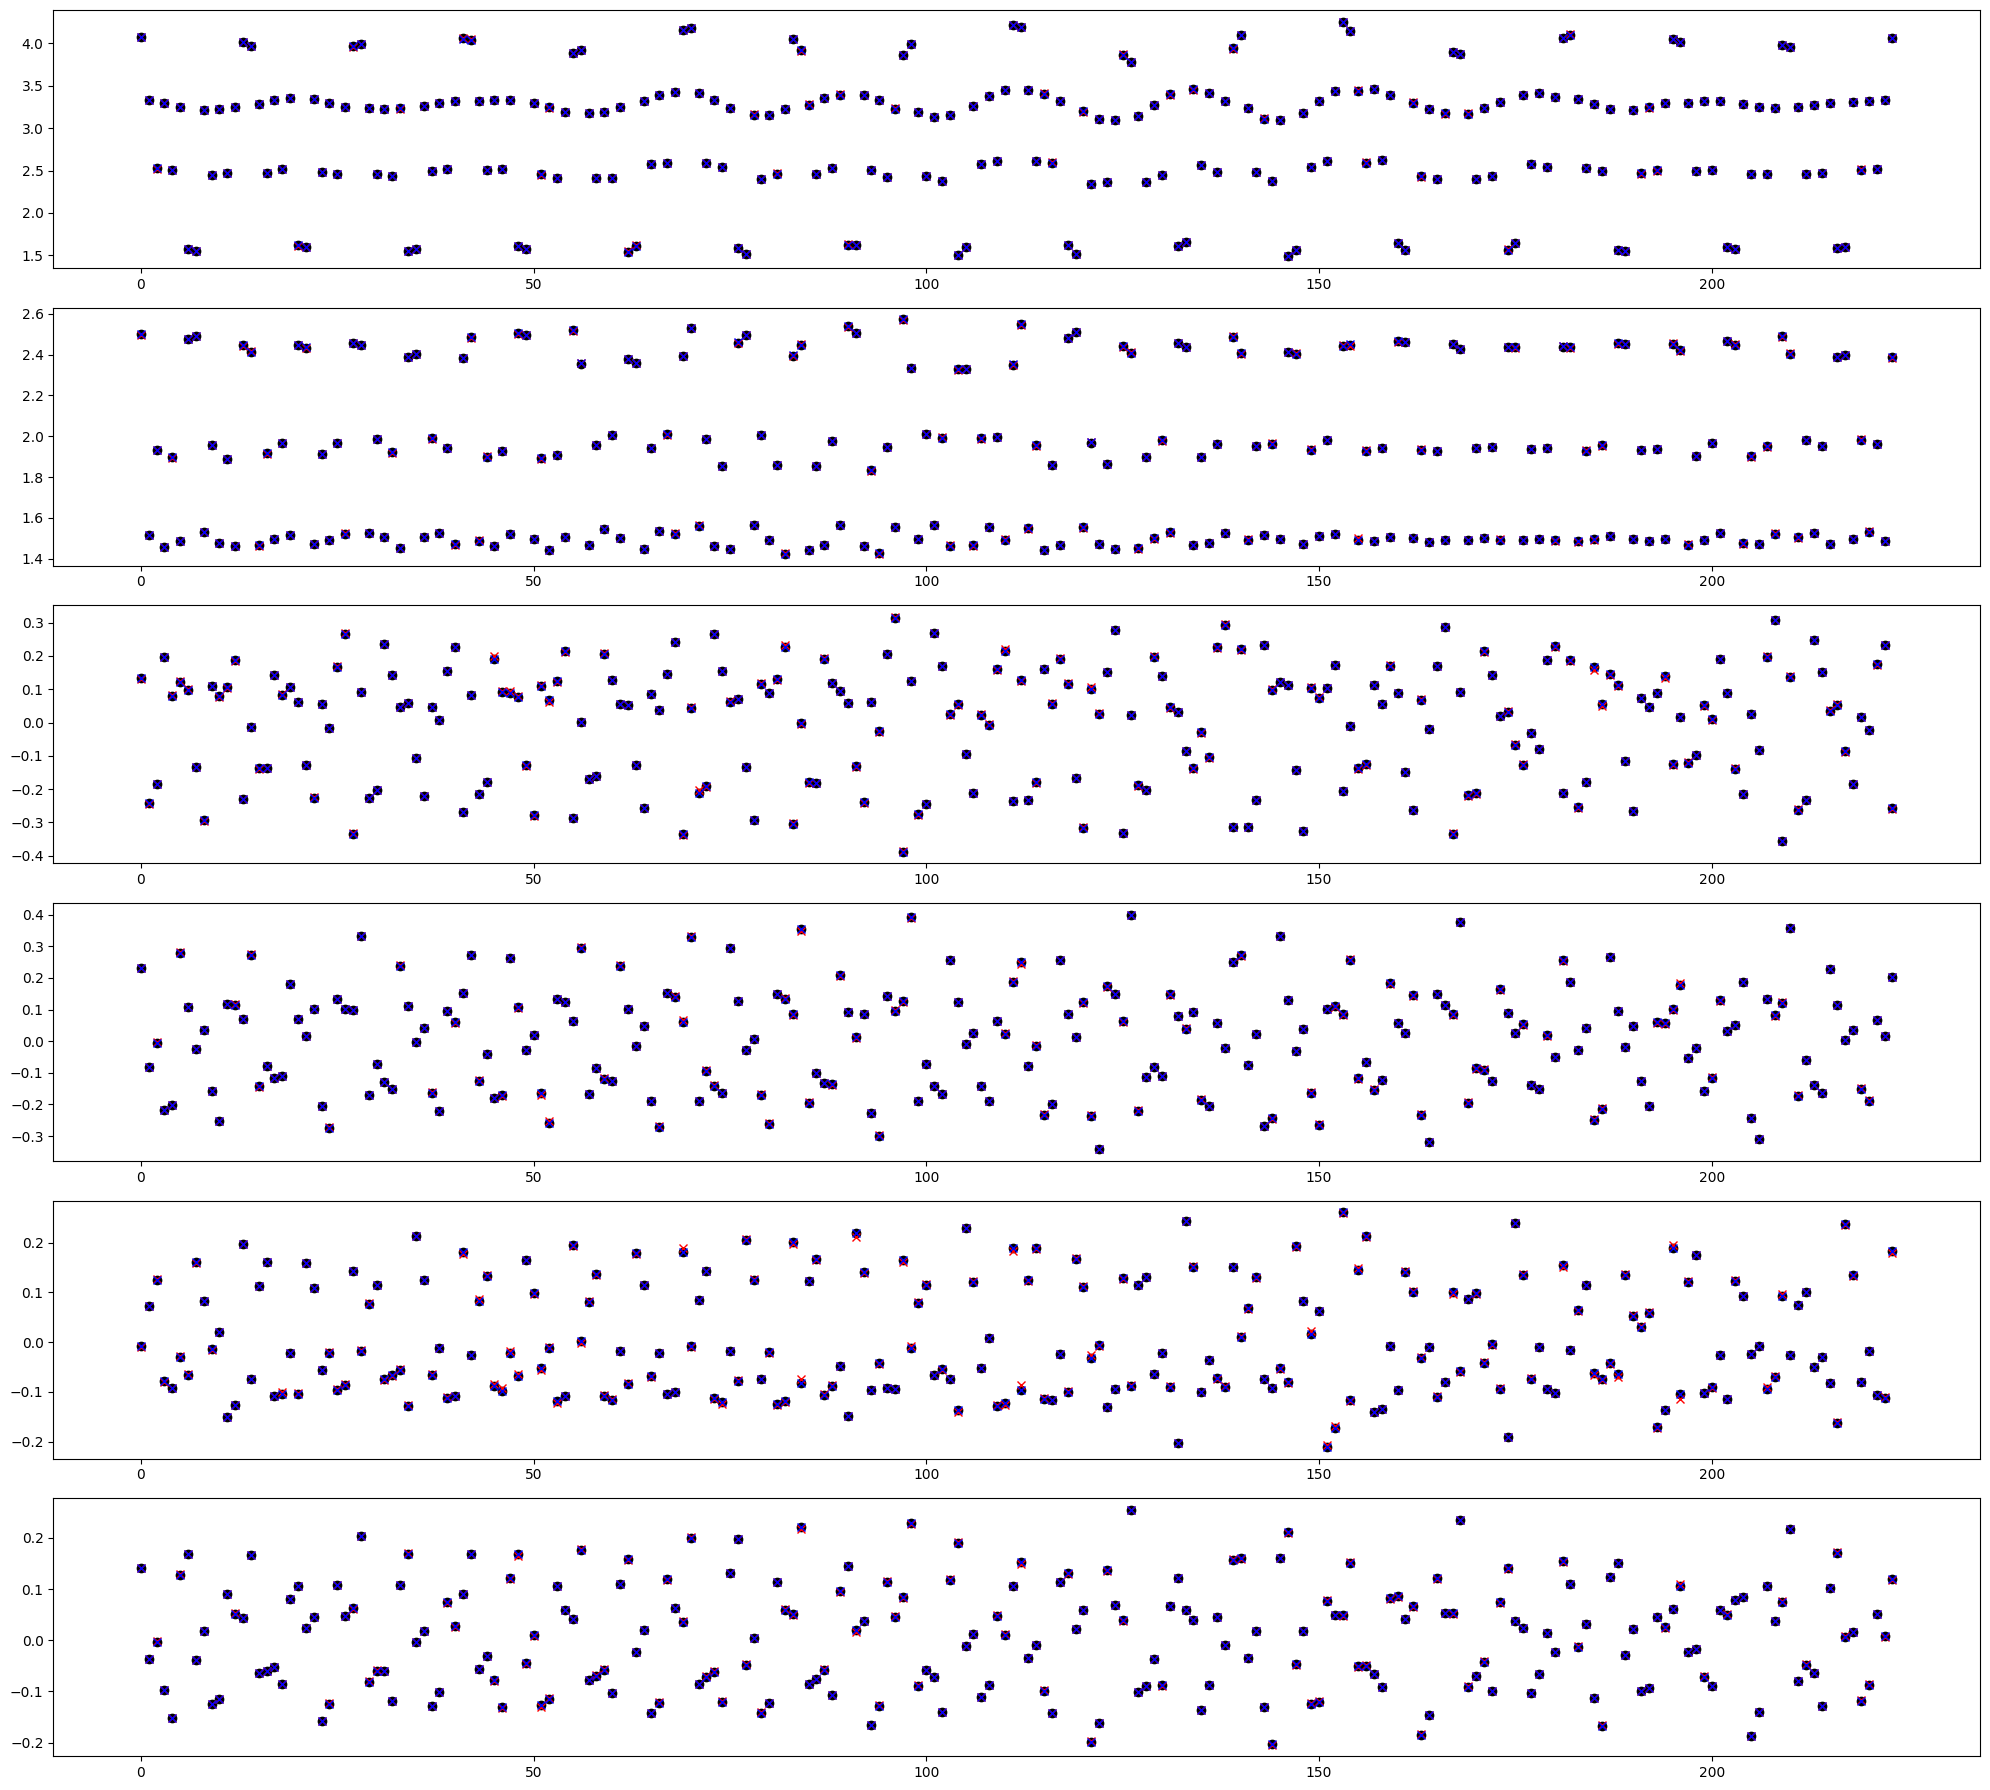

In [54]:
# Compute estimated normalization matrix element and with compare exact and fitted values

n11_estimate = axx/(2*ix_fit).sqrt()
n33_estimate = ayy/(2*iy_fit).sqrt()
n13_estimate = axy/ayy*(fxy - fyy).cos()*n33_estimate
n14_estimate = axy/ayy*(fxy - fyy).sin()*n33_estimate
n31_estimate = ayx/axx*(fyx - fxx).cos()*n11_estimate
n32_estimate = ayx/axx*(fyx - fxx).sin()*n11_estimate

plt.figure(figsize=(20, 3*6))

ax = plt.subplot(611)
ax.errorbar(range(model.monitor_count), n11.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), value_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), n11_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print(root_mean_square(n11 - n11_estimate))
print()

ax = plt.subplot(612)
ax.errorbar(range(model.monitor_count), n33.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), value_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), n33_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print(root_mean_square(n33 - n33_estimate))
print()

ax = plt.subplot(613)
ax.errorbar(range(model.monitor_count), n13.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), value_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), n13_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print(root_mean_square(n13 - n13_estimate))
print()

ax = plt.subplot(614)
ax.errorbar(range(model.monitor_count), n14.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), value_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), n14_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print(root_mean_square(n14 - n14_estimate))
print()

ax = plt.subplot(615)
ax.errorbar(range(model.monitor_count), n31.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), value_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), n31_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print(root_mean_square(n31 - n31_estimate))
print()

ax = plt.subplot(616)
ax.errorbar(range(model.monitor_count), n32.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), value_n32.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), n32_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n32 - value_n32))
print(root_mean_square(n32 - n32_estimate))
print()

plt.tight_layout()
plt.show()

# As it can be seen from rms values, accuracy in significantly improved

## Normalization matrix elements (momenta)

In [55]:
# Set twiss parameters

normal = model.out_normal[model.monitor_index]

n11 = normal[:, 0, 0]
n12 = normal[:, 0, 1]
n13 = normal[:, 0, 2]
n14 = normal[:, 0, 3]

n21 = normal[:, 1, 0]
n22 = normal[:, 1, 1]
n23 = normal[:, 1, 2]
n24 = normal[:, 1, 3]

n31 = normal[:, 2, 0]
n32 = normal[:, 2, 1]
n33 = normal[:, 2, 2]
n34 = normal[:, 2, 3]

n41 = normal[:, 3, 0]
n42 = normal[:, 3, 1]
n43 = normal[:, 3, 2]
n44 = normal[:, 3, 3]

twiss.normal[model.monitor_index] = value_normal
twiss.model.model = 'coupled'

In [56]:
# Estimate momenta (using estimated transport from fit)

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 2**10, location, 1, twiss.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 1024])


In [57]:
# Set reconstructed coordinates

Qx, Px, Qy, Py = orbit.swapaxes(0, 1)

In [58]:
# Set containers

length:int = 2**10

window:Window = Window.from_cosine(length, 2.0, dtype=dtype, device=device)

tbt_x:Data = Data(model.monitor_count, window)
tbt_y:Data = Data(model.monitor_count, window)

f_x:Frequency = Frequency(tbt_x)
f_y:Frequency = Frequency(tbt_y)

d_x:Decomposition = Decomposition(tbt_x)
d_y:Decomposition = Decomposition(tbt_y)

In [59]:
# Decomposition (exact coordinates)

tbt_x.data = qx[:, 1:length+1].clone()
tbt_x.work = qx[:, 1:length+1].clone()
tbt_x.reset()

tbt_y.data = qy[:, 1:length+1].clone()
tbt_y.work = qy[:, 1:length+1].clone()
tbt_y.reset()

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

axx, _, _ = d_x.harmonic_amplitude(nux, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxx, _, _ = d_x.harmonic_phase(nux, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayy, _, _ = d_y.harmonic_amplitude(nuy, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyy, _, _ = d_y.harmonic_phase(nuy, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

axy, _, _ = d_x.harmonic_amplitude(nuy, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxy, _, _ = d_x.harmonic_phase(nuy, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayx, _, _ = d_y.harmonic_amplitude(nux, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyx, _, _ = d_y.harmonic_phase(nux, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

In [60]:
# Decomposition (exact momenta)

tbt_x.data = px[:, 1:length+1].clone()
tbt_x.work = px[:, 1:length+1].clone()
tbt_x.reset()

tbt_y.data = py[:, 1:length+1].clone()
tbt_y.work = py[:, 1:length+1].clone()
tbt_y.reset()

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

paxx, _, _ = d_x.harmonic_amplitude(nux, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
pfxx, _, _ = d_x.harmonic_phase(nux, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
payy, _, _ = d_y.harmonic_amplitude(nuy, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
pfyy, _, _ = d_y.harmonic_phase(nuy, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

paxy, _, _ = d_x.harmonic_amplitude(nuy, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
pfxy, _, _ = d_x.harmonic_phase(nuy, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
payx, _, _ = d_y.harmonic_amplitude(nux, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
pfyx, _, _ = d_y.harmonic_phase(nux, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

In [61]:
# Decomposition (reconstructed momenta)

tbt_x.data = Px.clone()
tbt_x.work = Px.clone()
tbt_x.reset()

tbt_y.data = Py.clone()
tbt_y.work = Py.clone()
tbt_y.reset()

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

Paxx, _, _ = d_x.harmonic_amplitude(nux, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
Pfxx, _, _ = d_x.harmonic_phase(nux, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
Payy, _, _ = d_y.harmonic_amplitude(nuy, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
Pfyy, _, _ = d_y.harmonic_phase(nuy, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

Paxy, _, _ = d_x.harmonic_amplitude(nuy, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
Pfxy, _, _ = d_x.harmonic_phase(nuy, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
Payx, _, _ = d_y.harmonic_amplitude(nux, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
Pfyx, _, _ = d_y.harmonic_phase(nux, length=2**9, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

In [62]:
# Compare parameters

print(root_mean_square(paxx - Paxx))
print(root_mean_square(paxy - Paxy))
print(root_mean_square(payx - Payx))
print(root_mean_square(payy - Payy))
print()

print(root_mean_square((pfxx - Pfxx).cos()))
print(root_mean_square((pfxy - Pfxy).cos()))
print(root_mean_square((pfyx - Pfyx).cos()))
print(root_mean_square((pfyy - Pfyy).cos()))
print()

print(root_mean_square((pfxx - Pfxx).sin()))
print(root_mean_square((pfxy - Pfxy).sin()))
print(root_mean_square((pfyx - Pfyx).sin()))
print(root_mean_square((pfyy - Pfyy).sin()))
print()

tensor(2.0856e-07, dtype=torch.float64)
tensor(2.7258e-07, dtype=torch.float64)
tensor(2.8001e-07, dtype=torch.float64)
tensor(3.3459e-07, dtype=torch.float64)

tensor(1.0000, dtype=torch.float64)
tensor(0.9994, dtype=torch.float64)
tensor(0.9997, dtype=torch.float64)
tensor(1.0000, dtype=torch.float64)

tensor(0.0041, dtype=torch.float64)
tensor(0.0340, dtype=torch.float64)
tensor(0.0240, dtype=torch.float64)
tensor(0.0027, dtype=torch.float64)



In [63]:
# Compute elements (exact invariants and momenta)

n21_estimate = paxx/(2*ix).sqrt()*(pfxx - fxx).cos()
n22_estimate = paxx/(2*ix).sqrt()*(pfxx - fxx).sin()
n23_estimate = paxy/(2*iy).sqrt()*(pfxy - fyy).cos()
n24_estimate = paxy/(2*iy).sqrt()*(pfxy - fyy).sin()
n41_estimate = payx/(2*ix).sqrt()*(pfyx - fxx).cos()
n42_estimate = payx/(2*ix).sqrt()*(pfyx - fxx).sin()
n43_estimate = payy/(2*iy).sqrt()*(pfyy - fyy).cos()
n44_estimate = payy/(2*iy).sqrt()*(pfyy - fyy).sin()

print(root_mean_square(n21_estimate - n21))
print(root_mean_square(n22_estimate - n22))
print(root_mean_square(n23_estimate - n23))
print(root_mean_square(n24_estimate - n24))
print(root_mean_square(n41_estimate - n41))
print(root_mean_square(n42_estimate - n42))
print(root_mean_square(n43_estimate - n43))
print(root_mean_square(n44_estimate - n44))

tensor(8.8010e-10, dtype=torch.float64)
tensor(2.1680e-10, dtype=torch.float64)
tensor(5.7290e-09, dtype=torch.float64)
tensor(5.5079e-09, dtype=torch.float64)
tensor(5.5903e-09, dtype=torch.float64)
tensor(5.4449e-09, dtype=torch.float64)
tensor(3.5168e-10, dtype=torch.float64)
tensor(2.1021e-10, dtype=torch.float64)


In [64]:
# Compute elements (fitted invariants and reconstructed momenta) and compare with fitted values

n21_estimate = Paxx/(2*ix_fit).sqrt()*(Pfxx - fxx).cos()
n22_estimate = Paxx/(2*ix_fit).sqrt()*(Pfxx - fxx).sin()
n23_estimate = Paxy/(2*iy_fit).sqrt()*(Pfxy - fyy).cos()
n24_estimate = Paxy/(2*iy_fit).sqrt()*(Pfxy - fyy).sin()
n41_estimate = Payx/(2*ix_fit).sqrt()*(Pfyx - fxx).cos()
n42_estimate = Payx/(2*ix_fit).sqrt()*(Pfyx - fxx).sin()
n43_estimate = Payy/(2*iy_fit).sqrt()*(Pfyy - fyy).cos()
n44_estimate = Payy/(2*iy_fit).sqrt()*(Pfyy - fyy).sin()

print(root_mean_square(value_n21 - n21))
print(root_mean_square(value_n22 - n22))
print(root_mean_square(value_n23 - n23))
print(root_mean_square(value_n24 - n24))
print(root_mean_square(value_n41 - n41))
print(root_mean_square(value_n42 - n42))
print(root_mean_square(value_n43 - n43))
print(root_mean_square(value_n44 - n44))
print()

print(root_mean_square(n21_estimate - n21))
print(root_mean_square(n22_estimate - n22))
print(root_mean_square(n23_estimate - n23))
print(root_mean_square(n24_estimate - n24))
print(root_mean_square(n41_estimate - n41))
print(root_mean_square(n42_estimate - n42))
print(root_mean_square(n43_estimate - n43))
print(root_mean_square(n44_estimate - n44))
print()

# Note, rms values for fitted twiss and twiss from harmonic analysis of reconstructed momenta are close

tensor(0.0015, dtype=torch.float64)
tensor(0.0005, dtype=torch.float64)
tensor(0.0013, dtype=torch.float64)
tensor(0.0008, dtype=torch.float64)
tensor(0.0021, dtype=torch.float64)
tensor(0.0008, dtype=torch.float64)
tensor(0.0029, dtype=torch.float64)
tensor(0.0008, dtype=torch.float64)

tensor(0.0016, dtype=torch.float64)
tensor(0.0007, dtype=torch.float64)
tensor(0.0014, dtype=torch.float64)
tensor(0.0008, dtype=torch.float64)
tensor(0.0020, dtype=torch.float64)
tensor(0.0008, dtype=torch.float64)
tensor(0.0023, dtype=torch.float64)
tensor(0.0008, dtype=torch.float64)



In [65]:
# With calibration errors, reconstructed momenta are effected by severals
# Thus, estimated parameters are not in BPM frame (should be still closer to it)
# A possible remedy is to use scaled TbT for momenta estimation
# In this case, estimated parameters are expected to be closer to beam frame

# First order expressions with respect to calibration parameters
# Note, here gxx is replaced by 1 + gxx and expansion is with respect to deviation, similar for gyy

# n21->n21+(-gxx n11 n21+gxy n22 n32-gyx n11 n41)/n11 -> (1 - gxx) n21  + O(gxy) + O(gyx)
# n22->n22+(-gxx n11 n22-gxy n21 n32-gyx n11 n42)/n11 -> (1 - gxx) n22 + O(gxy) + O(gyx)
# n23->n23+(gyx n14 n24-gxx n23 n33-gyx n33 n43)/n33  -> (1 - gxx) n23 + O(gxy) + O(gyx)
# n24->n24+(-gyx n14 n23-gxx n24 n33-gyx n33 n44)/n33 -> (1 - gxx) n24 + O(gxy) + O(gyx)

# n41->n41+(-gxy n11 n21-gyy n11 n41+gxy n32 n42)/n11 -> (1 - gyy) n41  + O(gxy) + O(gyx)
# n42->n42+(-gxy n11 n22-gxy n32 n41-gyy n11 n42)/n11 -> (1 - gyy) n42  + O(gxy) + O(gyx)
# n43->n43+(-gxy n23 n33-gyy n33 n43+gyx n14 n44)/n33 -> (1 - gyy) n43  + O(gxy) + O(gyx)
# n44->n44+(-gxy n24 n33-gyx n14 n43-gyy n33 n44)/n33 -> (1 - gyy) n44  + O(gxy) + O(gyx)